In [ ]:
pip install duckdb pandas numpy matplotlib Pyarrow 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np



In [2]:
import duckdb


In [6]:
## LOAD AND FILTER the main energy levels database

In [6]:
# Global variables to store energy data (loaded once)
energies_m = None
J_vals = None


def load_energy_data():
    """Load energy levels from database once"""
    global energies_m, J_vals
    if energies_m is None:
        conn = duckdb.connect('energylevels2.duckdb')
        df = conn.execute(
            "SELECT * FROM energy_levels WHERE el_state = 'X3Sigma-' and J < 165 and v < 42 ORDER BY energy" 
            ).df()
        conn.close()
        
        energies_cm = list(df.energy)
        J_vals = list(df.J)
        energies_m = [(energy_cm + 794.590195753252-791.716307 ) / 1e-2 for energy_cm in energies_cm]
        print(f"Loaded {len(energies_cm)} energy levels")

def Q(T_Kelvin, batch_size=500, tolerance=1e-5, verbose=False):

    """
    Calculate partition function Q for a given temperature
    
    Parameters:
    T_Kelvin: Temperature in Kelvin
    batch_size: Number of energy levels to process per batch
    tolerance: Convergence tolerance
    verbose: Print convergence information
    
    Returns:
    Q: Partition function value
    """
    # Load data if not already loaded
    load_energy_data()
    
    Q_val = 0.0
    Q_old = []
    
    if verbose:
        print(f"Calculating Q for T = {T_Kelvin} K")
    # Constants
    k_b = 1.380649e-23  # Boltzmann constant in J/K
    h = 6.62607015e-34  # Planck constant in J·s
    c = 299792458       # Speed of light in m/s
    cm_to_m = 1e-2      # Convert cm^-1 to m^-1
    # Loop in batches, convert each batch to Joules, accumulate Q
    for i in range(0, len(energies_m), batch_size):
        batch_m = energies_m[i:i + batch_size]
        batch_J = J_vals[i:i + batch_size]
        
        # Convert from cm^-1 to J: E(J) = E(cm^-1) * 100 * h * c
        batch_joules = [(e) * h * c for e in batch_m]
        
        # Calculate partition function contribution for each energy level
        batch_contribution = [(np.exp(-(e)/(k_b * T_Kelvin))) for e in batch_joules]
        batch_degeneracies = [2*J + 1 for J in batch_J]  # Degeneracy factor for each J
        batch_contribution = [contrib * deg for contrib, deg in zip(batch_contribution, batch_degeneracies)]
        
        batch_sum = sum(batch_contribution)
        
        Q_old.append(Q_val)
        Q_val += batch_sum
        
        # Check for convergence
        if abs(Q_val - Q_old[-1]) < tolerance:
            if verbose:
                print(f"Converged after batch {len(Q_old)}")
            break
    
    if verbose:
    
        print(f"Final Q = {Q_val:.6f}")
    
    return Q_val

In [7]:
conn = duckdb.connect('energylevels2.duckdb')

df = conn.execute(
            "SELECT * FROM energy_levels WHERE el_state = 'X3Sigma-'  ORDER BY energy"
            ).df()[['v', 'J', 'lambda', 'sigma', 'omega'
]].drop_duplicates().shape[0]
df

12642

In [8]:
Q(300)

Loaded 10306 energy levels


218.49885813081738

In [38]:
ls -lh

total 1.1G
-rw-r--r--. 1 pagrawala6 pace-js130 2.4M Mar 30 07:40  0_beginning.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 676K Mar 21 13:20  1_discretebands.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 550K Mar 21 13:22  2_cont_preanalysis.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 960K Mar 30 07:10  3_cont_spectraanalysis.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 260K Mar 30 13:29  4_discretepol.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 3.2M Apr  5 22:25  5_mainpolanalysis.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130  29K Mar 30 13:11  alpha_vs_J.pdf
-rw-r--r--. 1 pagrawala6 pace-js130  56K Mar 30 07:03  cont_1.svg
-rw-r--r--. 1 pagrawala6 pace-js130  25K Mar 30 07:10  cont_4.2.pdf
-rw-r--r--. 1 pagrawala6 pace-js130 1.1K Mar 30 07:08  cont_4.svg
-rw-r--r--. 1 pagrawala6 pace-js130  57K Mar 26 11:43  cross_section_comparison.pdf
-rw-r--r--. 1 pagrawala6 pace-js130  36M Mar 26 02:46  cross_sections.parquet
-rw-r--r--. 1 pagrawala6 pace-js130 230K Mar 30 13:59  dis_con_pol_j10.png
-rw-r--r--. 1 

In [5]:
cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/"

/storage/project/r-js130-0/pagrawala6/thesisplots


In [9]:
import duckdb
from pathlib import Path

# Absolute paths for the A-E workflow
case_ids = ['A', 'B', 'C', 'D', 'E']
active_cases = case_ids.copy()

ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Input transition databases
case_db_paths = {
    case: ABS_TEST_DIR / f'{case}.duckdb'
    for case in case_ids
}

# Output polarizability databases
case_pol_db_paths = {
    case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb'
    for case in case_ids
}

# Common discrete polarizability source. This is copied into each A-E output DB
# so downstream cells can keep using the same JOIN structure.
REFERENCE_POL_DB_PATH = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb')
COMBINED_POL_DB_PATH = ABS_TEST_DIR / 'testcase_polarizabilities.duckdb'

full_conn_by_case = {
    case: duckdb.connect(str(case_db_paths[case]))
    for case in case_ids
}

print("Loaded transition DB connections:")
for case in case_ids:
    print(f"  {case}: {case_db_paths[case]}")


Loaded transition DB connections:
  A: /storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests/A.duckdb
  B: /storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests/B.duckdb
  C: /storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests/C.duckdb
  D: /storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests/D.duckdb
  E: /storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests/E.duckdb


In [10]:
# is this above the dissociation limit?

print (f'The dissociation limit, as specified in the input B state PEC, is 57830 cm^-1 whereas the minimum energy of the upper state in the contiuum database is:')
full_conn.execute("SELECT MIN(up_energy) AS min_up_energy FROM duo_oxygen1616_schumannrunge").df()



# Does this mean that our filters on the probability density are NOT tight enough?\n ")


The dissociation limit, as specified in the input B state PEC, is 57830 cm^-1 whereas the minimum energy of the upper state in the contiuum database is:


NameError: name 'full_conn' is not defined

## BEGIN Main database queries for all computations: 
Note that any filters on the transitions to be used have to be applied AT this step, say restricting the v, J, up_energy etc. 
#### REMEMBER to also synchronize the same filters with the energy levels database

In [11]:
# Load continuum data for each case
continuum_by_case = {}

for case in case_ids:
    continuum_by_case[case] = full_conn_by_case[case].execute("""
        SELECT *
        FROM duo_oxygen1616_schumannrunge
        WHERE down_energy < 42025
          AND down_J < 125
          AND down_v < 25
          AND up_energy > 57840
    """).df()
    continuum_by_case[case]['case'] = case

# Backward-compatible single-case aliases for older exploratory cells.
# The A-E workflow below uses continuum_by_case/continuum_grouped_by_case.
continuum = continuum_by_case['A']

print("Loaded continuum data:")
for case in active_cases:
    print(f"  {case}: {len(continuum_by_case[case]):,} rows")


Loaded continuum data:
  A: 10,701,126 rows
  B: 10,549,433 rows
  C: 10,487,978 rows
  D: 13,014,287 rows
  E: 12,905,300 rows


In [12]:
# get max and min of line_pos

for case in case_ids:    
    max_line_pos = continuum_by_case[case]["line_pos"].max()
    min_line_pos = continuum_by_case[case]["line_pos"].min()

    print(f"Maximum line_pos: {max_line_pos}")
    print(f"Minimum line_pos: {min_line_pos}")

Maximum line_pos: 119999.9876
Minimum line_pos: 16119.4944
Maximum line_pos: 119999.9793
Minimum line_pos: 16147.3541
Maximum line_pos: 119999.9683
Minimum line_pos: 16113.3887
Maximum line_pos: 119997.9746
Minimum line_pos: 16138.3038
Maximum line_pos: 119999.6057
Minimum line_pos: 16114.6349


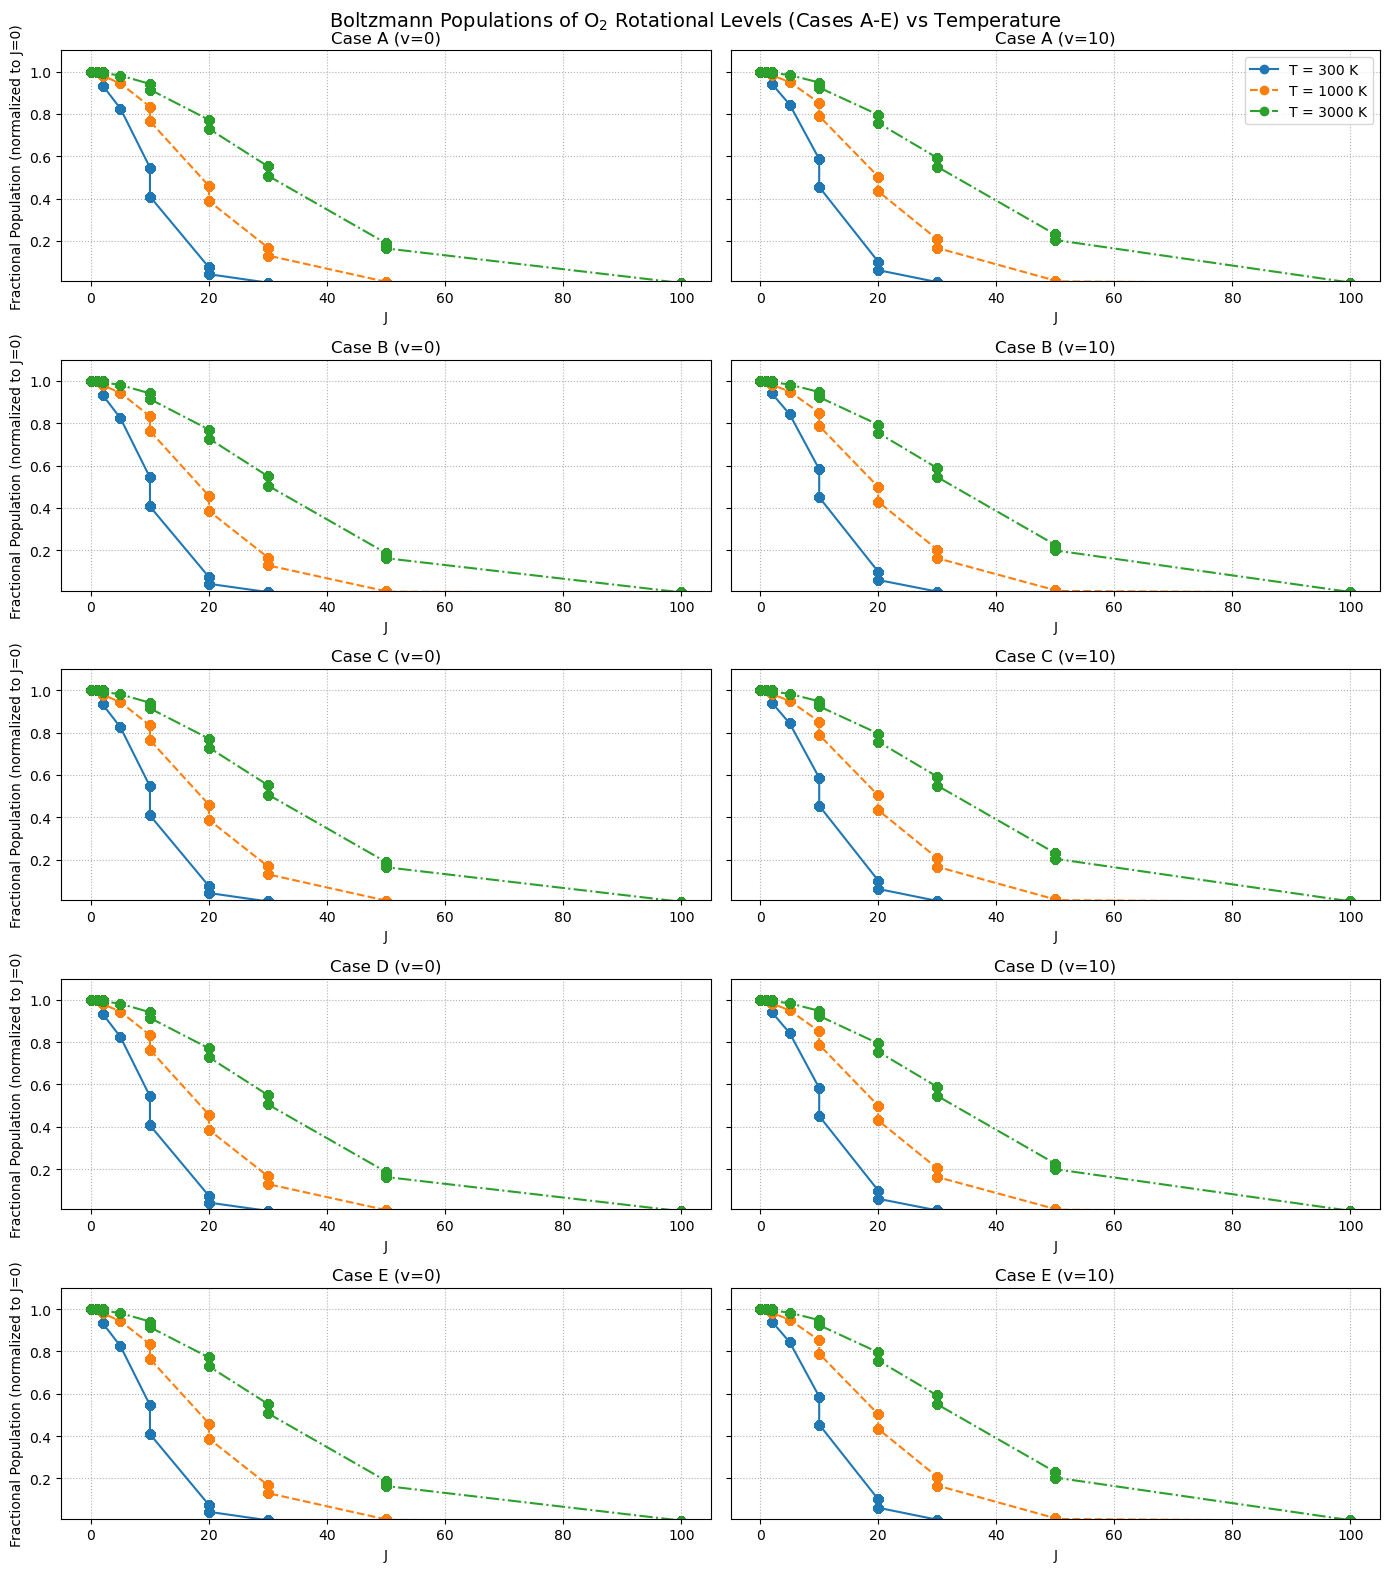

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
k_B = 0.69503476  # cm^-1/K (Boltzmann constant in spectroscopic units)
T_list = [300, 1000, 3000]
J_values = [0, 1, 2, 5, 10, 20, 30, 50, 100]
cases = ['A', 'B', 'C', 'D', 'E']

# Color and linestyle mapping for temperatures
T_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
T_linestyles = ['-', '--', '-.']

# Grid: 5 rows (cases A-E) × 2 columns (v=0, v=10)
fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharey=True)

for case_idx, case in enumerate(cases):
    for v_idx, v in enumerate([0, 10]):
        ax = axes[case_idx, v_idx]
        
        # Retrieve continuum data for this case
        v_df = continuum_by_case[case][continuum_by_case[case]["down_v"] == v]
        subset = v_df[v_df["down_J"].isin(J_values)].copy()
        
        # Add case identifier
        subset['case'] = case
        
        for T_idx, T in enumerate(T_list):
            # Boltzmann factor
            subset[f"pop_T{T}"] = np.exp(-subset["down_energy"] / (k_B * T))
            
            # Normalize wrt J=0 population
            norm_factor = subset[subset["down_J"] == 0][f"pop_T{T}"].values[0]
            subset[f"pop_T{T}_frac"] = subset[f"pop_T{T}"] / norm_factor
            
            # Plot with temperature-specific color and linestyle
            ax.plot(
                subset["down_J"],
                subset[f"pop_T{T}_frac"],
                color=T_colors[T_idx],
                linestyle=T_linestyles[T_idx],
                marker="o",
                label=f"T = {T} K"
            )
        
        ax.set_xlabel("J")
        ax.set_title(f"Case {case} (v={v})")
        ax.grid(True, which="both", linestyle=":")
        ax.set_ylim(0.01, 1.1)
        
        # Legend only on first row, right column
        if case_idx == 0 and v_idx == 1:
            ax.legend(loc='upper right')

# Shared ylabel on left column
for case_idx in range(5):
    axes[case_idx, 0].set_ylabel("Fractional Population (normalized to J=0)")

fig.suptitle("Boltzmann Populations of O$_2$ Rotational Levels (Cases A-E) vs Temperature", fontsize=14)
plt.tight_layout()
plt.show()

## Begin "grouping" by lower energy level

In [14]:
# num_unique_lower_levelsd = discrete[[
#     'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
# ]].drop_duplicates().shape[0]
# num_unique_lower_levelsc = continuum[[
#     'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
# ]].drop_duplicates().shape[0]    
num_unique_lower_levelsc = continuum[[
    'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
]].drop_duplicates().shape[0]

# num_unique_lower_levelsd = discrete[[
#     'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
# ]].drop_duplicates().shape[0]
# num_unique_lower_levelsc = continuum[[
#     'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
# ]].drop_duplicates().shape[0]    
num_unique_lower_levelsc = continuum[[
    'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
]].drop_duplicates().shape[0]


levels = conn.execute("""
SELECT *
FROM energy_levels where J<151 and v<26 and el_state = 'X3Sigma-'
""").df()

num_X_levels = levels[[
    'v', 'J', 'lambda', 'sigma', 'omega',
]].drop_duplicates().shape[0]



print(f"Number of unique lower levels continuum:{num_unique_lower_levelsc} and Number of unique lower levels discrete:__ BUT in the energy levels database = {num_X_levels}" , ) # Ensure that the number here matches the "parse_levels" code for the partition function



levels = conn.execute("""
SELECT *
FROM energy_levels where J<151 and v<26 and el_state = 'X3Sigma-'
""").df()

num_X_levels = levels[[
    'v', 'J', 'lambda', 'sigma', 'omega',
]].drop_duplicates().shape[0]



print(f"Number of unique lower levels continuum:{num_unique_lower_levelsc} and Number of unique lower levels discrete:__ BUT in the energy levels database = {num_X_levels}" , ) # Ensure that the number here matches the "parse_levels" code for the partition function




Number of unique lower levels continuum:3845 and Number of unique lower levels discrete:__ BUT in the energy levels database = 5876
Number of unique lower levels continuum:3845 and Number of unique lower levels discrete:__ BUT in the energy levels database = 5876


In [15]:
# Group continuum data for each case
continuum_grouped_by_case = {}

for case in case_ids:
    continuum_grouped_by_case[case] = continuum_by_case[case].groupby(
        ['down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy']
    ).agg({
        'A': list,
        'line_pos': list,
        'up_energy': list,
        'up_J': list,
        'up_v': list
    }).reset_index()
    continuum_grouped_by_case[case]['case'] = case

# Backward-compatible single-case alias.
continuum_grouped = continuum_grouped_by_case['A']

print("Grouped continuum data:")
for case in active_cases:
    print(f"  {case}: {len(continuum_grouped_by_case[case]):,} lower-state groups")


Grouped continuum data:
  A: 3,845 lower-state groups
  B: 3,845 lower-state groups
  C: 3,845 lower-state groups
  D: 3,845 lower-state groups
  E: 3,845 lower-state groups


Text(0.5, 1.0, 'Einstein A vs Wavelength (nm) - Continuum Only')

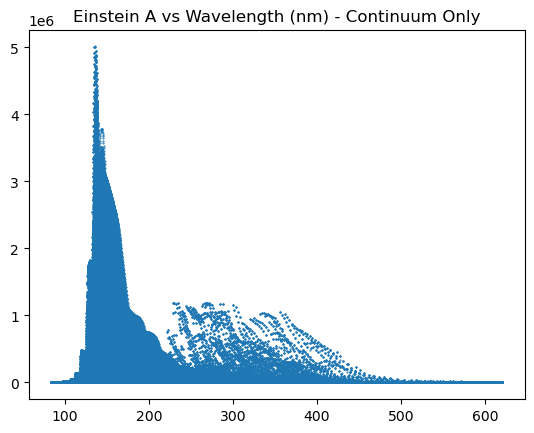

In [16]:
plt.plot(1e7/continuum['line_pos'], continuum['A'], '.', markersize=1)
plt.title("Einstein A vs Wavelength (nm) - Continuum Only")

In [17]:
# Extract energy data from case A for Q function setup
down_J_list = continuum_grouped_by_case['A']['down_J'].tolist()
down_energy_list = continuum_grouped_by_case['A']['down_energy'].tolist()

In [18]:
print(Q(3000))
Q(300)

4269.452834522348


218.49885813081738

In [19]:
# Parallel computation of the cross-section
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import threading
from typing import Tuple, List
import time
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K

T = 300  # Temperature in Kelvin
Q_T = Q(T)  # Partition function at temperature T


def gaussian_lineprofile(nu, nu_nominal, alpha_D):
    """Compute Gaussian line profile"""
    return np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * np.exp(-np.log(2) * (nu - nu_nominal)**2 / alpha_D**2)

def process_transition_chunk_vectorized(args):
    """
    Process a chunk of transitions using vectorized operations with frequency masking
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    cutoff_range = 2.8 * alpha_D
    
    # Vectorized computation for this chunk
    # Create 2D arrays: (n_transitions, n_frequencies)
    nu_grid = nu_range[np.newaxis, :]  # Shape: (1, n_freq)
    pos_grid = line_positions[:, np.newaxis]  # Shape: (n_trans, 1)
    
    # Apply frequency masking: only compute within cutoff range
    mask = np.abs(nu_grid - pos_grid) <= cutoff_range
    
    # Compute Gaussian contributions only where mask is True
    distances = nu_grid - pos_grid
    gaussians = np.zeros_like(distances)
    
    # Only compute Gaussian where mask is True (keeps your masking logic)
    gaussians[mask] = (np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * 
                      np.exp(-np.log(2) * distances[mask]**2 / alpha_D**2))
    
    # Weight by intensities and sum along transition axis
    weighted = gaussians * intensities[:, np.newaxis]
    local_cross_section = np.sum(weighted, axis=0)
    
    return local_cross_section

def process_transition_chunk(args):
    """
    Process a chunk of transitions with frequency masking and accumulate contributions
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    
    # Process each transition in this chunk
    for central_position, intensity in zip(line_positions, intensities):
        # Apply frequency masking: only compute within 5 Doppler widths
        cutoff_range = 2.8 * alpha_D
        mask = (nu_range >= central_position - cutoff_range) & (nu_range <= central_position + cutoff_range)
        
            
        # Compute Gaussian contribution only for masked region
        masked_nu = nu_range[mask]
        contribution = intensity * gaussian_lineprofile(masked_nu, central_position, alpha_D)
        
        # Add contribution to local cross-section
        local_cross_section[mask] += contribution
    
    return local_cross_section

def compute_cross_section_optimized(line_positions, intensities, nu_range, alpha_D, 
                                  num_chunks=4, num_threads=None):
    """
    Compute cross-section using chunking and multithreading with frequency masking
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D: Doppler width parameter
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section: final cross-section array
    """
    total_transitions = len(line_positions)
    # print(f"Processing {total_transitions:,} transitions in {num_chunks} chunks")
    
    # Initialize final cross-section array
    cross_section = np.zeros_like(nu_range)
    
    # Calculate chunk size
    chunk_size = total_transitions // num_chunks
    
    # Process each chunk
    for chunk_idx in range(num_chunks):
        start_idx = chunk_idx * chunk_size
        if chunk_idx == num_chunks - 1:  # Last chunk gets remaining transitions
            end_idx = total_transitions
        else:
            end_idx = (chunk_idx + 1) * chunk_size
        
        chunk_line_positions = line_positions[start_idx:end_idx]
        chunk_intensities = intensities[start_idx:end_idx]
        
        # print(f"Processing chunk {chunk_idx + 1}/{num_chunks} "
        #       f"({len(chunk_line_positions):,} transitions)")
        
        # Further divide chunk for multithreading
        if num_threads is None:
            import os
            num_threads = os.cpu_count()
        
        thread_chunk_size = len(chunk_line_positions) // num_threads
        thread_args = []
        
        for thread_idx in range(num_threads):
            thread_start = thread_idx * thread_chunk_size
            if thread_idx == num_threads - 1:  # Last thread gets remaining
                thread_end = len(chunk_line_positions)
            else:
                thread_end = (thread_idx + 1) * thread_chunk_size
            
            if thread_start < len(chunk_line_positions):
                thread_args.append((
                    chunk_line_positions[thread_start:thread_end],
                    chunk_intensities[thread_start:thread_end],
                    nu_range,
                    alpha_D,
                    thread_idx
                ))
        
        # Execute multithreaded computation for this chunk
        start_time = time.time()
        with ThreadPoolExecutor(max_workers=num_threads) as executor:
            results = list(executor.map(process_transition_chunk_vectorized, thread_args))
        
        # Accumulate results from all threads
        for result in results:
            cross_section += result
        
        chunk_time = time.time() - start_time
        # print(f"Chunk {chunk_idx + 1} completed in {chunk_time:.2f}s")
    
    return cross_section

def compute_cross_section_batch_optimized(line_positions, intensities, nu_range, alpha_D_list, 
                                        num_chunks=4, num_threads=None):
    """
    Compute cross-sections for multiple alpha_D values using optimized approach
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D_list: list of Doppler width parameters
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section_list: list of cross-section arrays
    """
    cross_section_list = []
    
    for i, alpha_D in enumerate(alpha_D_list):
        # print(f"\nProcessing alpha_D = {alpha_D} ({i+1}/{len(alpha_D_list)})")
        start_time = time.time()
        
        cross_section = compute_cross_section_optimized(
            line_positions, intensities, nu_range, alpha_D, 
            num_chunks, num_threads
        )
        
        cross_section_list.append(cross_section)
        
        total_time = time.time() - start_time
        # print(f"Alpha_D = {alpha_D} completed in {total_time:.2f}s")
    
    return cross_section_list



In [21]:
# Example usage with your data
def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks =4):
    # Set up frequency range
    
    
    n_transitions = len (intensities)  # 14 million transitions
    
    print(f"Starting computation with {len(line_positions):,} transitions")
    print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm⁻¹")
    print(f"Alpha_D values: {alpha_D_list}")
    
    # Run optimized computation
    start_time = time.time()
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions, intensities, nu_range, alpha_D_list,
        num_chunks, num_threads=None  # Auto-detect thread count
    )
    
    total_time = time.time() - start_time
    print(f"\nTotal computation time: {total_time:.2f}s")
    print(f"Cross-section shapes: {[cs.shape for cs in cross_section_list]}")
    
    return cross_section_list




if __name__ == "__main__":
    # alpha_D_list = [300,1500, 3000, 5000] 
    alpha_D_list = [0.003, 3,30] 
    alpha_D_list = [30,300] 
    alpha_D_list = [15] 
    alpha_D_list = [30,150] 
    alpha_D_list = [160] 


    nu_range = np.linspace(1e7/180, 1e7/100, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/550, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/750, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/600, 1e7/90, 6000)  # in cm⁻¹
    nu_range = np.linspace(1e7/200, 1e7/110, 10000)  # in cm⁻¹
    continuum['Intensity'] = 0
    continuum['Intensity'] = continuum['A'] * (2 * continuum['up_J'] + 1) * np.exp(-(h*c*(continuum['down_energy']-2.86)/(k_B * T)))  / (8.0 * np.pi*c * continuum['line_pos']**(2) * Q_T)
    

    df = continuum.sort_values(by='line_pos', ascending=True)
    
    line_positions = df['line_pos'].values
    intensities = df['Intensity'].values
    
    
    cross_section_list = []
    # CALLING THE MAIN CROSS-SECTION FUNCTION:
    cross_section_list = main(alpha_D_list, nu_range, line_positions, intensities, 7)
    
    
    # doing 4 chunks at this time, can decrease if each "list" is smaller or larger, remember that each "chunk" is then parallelized, so chunks are really number of passes

Starting computation with 10,701,126 transitions
Frequency range: 50000.0 to 90909.1 cm⁻¹
Alpha_D values: [160]

Total computation time: 26.21s
Cross-section shapes: [(10000,)]


In [22]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import io

def plot_exomol_o2_cross_section(temperature):
    """
    Fetches, parses, and plots O2 photodissociation cross-sections
    from ExoMol for a given temperature.
    """
    # 1. Construct the URL for the desired temperature
    url = f"https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__{temperature}__0__0.1.photo"
    print(f"Fetching data for T = {temperature} K from {url}")

    try:
        # 2. Fetch the data
        response = requests.get(url)
        response.raise_for_status()  # Raises an exception for bad status codes (404, 500, etc.)

        # 3. Use io.StringIO to treat the text content as a file in memory
        #    The data is whitespace-delimited.
        data_file = io.StringIO(response.text)

        # 4. Load the data directly into NumPy arrays
        #    The first column is wavelength (nm), the second is cross-section (cm^2)
        wavelength, cross_section = np.loadtxt(data_file, unpack=True)
        
        # 5. Plot for validation
        # plt.style.use('seaborn-v0_8-whitegrid')
        # fig, ax = plt.subplots(figsize=(10, 6))

        # ax.plot(wavelength, cross_section)

        # ax.set_xlabel('Wavelength (nm)')
        # ax.set_ylabel(r'Cross Section ($cm^{2} \, molecule^{-1}$)')
        # ax.set_title('Absorption Cross Section vs Wavelength (T = 3000 K)')
        # ax.grid(True, which="both", ls="--")
        # ax.set_xlim(130, 180)
        # ax.set_ylim(1e-20, 0.5e-16)
        # ax.set_yscale('log') # Cross-sections often span many orders of magnitude
        

        # plt.show()
        return wavelength, cross_section

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- Run the function for a specific temperature ---
plot_exomol_o2_cross_section(temperature=300)

Fetching data for T = 300 K from https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__300__0__0.1.photo


(array([ 50. ,  50.1,  50.2, ..., 499.8, 499.9, 500. ]),
 array([2.17e-22, 1.48e-22, 8.37e-23, ..., 1.79e-80, 1.76e-80, 1.74e-80]))

Fetching data for T = 300 K from https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__300__0__0.1.photo
Integrated cross-section for α_D=160: 1.4393e-13


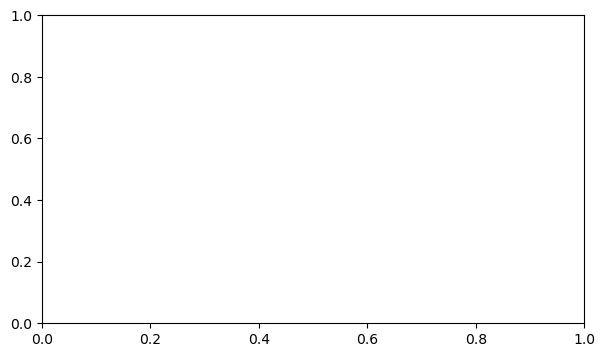

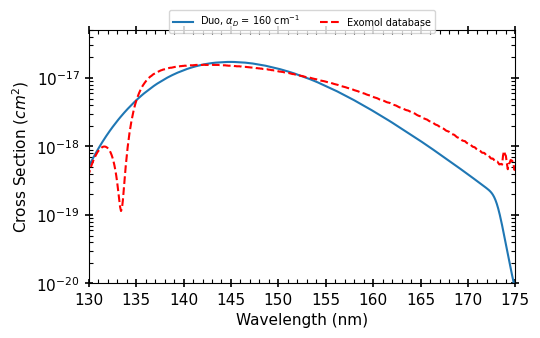

In [23]:
import duckdb

import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np   # (already imported earlier, but kept for completeness)
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
from multiprocessing import Pool, cpu_count
from functools import partial
import time
# validation_data = pd.read_csv('Yoshino_2005.csv')
# validation_x = validation_data.iloc[:, 0]
# validation_y = validation_data.iloc[:, 1]

# validation_data = pd.read_csv('Lu_2010.csv')
# validation_x_3 = validation_data.iloc[:, 0]
# validation_y_3 = validation_data.iloc[:, 1]

validation_x_2,validation_y_2 = plot_exomol_o2_cross_section(T)

# === Plot ===
# fig, ax = plt.subplots(figsize=(12, 4.5))
fig, ax = plt.subplots(figsize=(7, 4))
fig, ax = plt.subplots(figsize=(5.5, 3.5))

ax.set_xlabel('Wavelength (nm)', fontsize=11)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=11)
# ax.set_title(f'Absorption Cross Section vs Wavelength (T = {T} K)')
ax.set_xlim(130, 180)
ax.set_xlim(130, 175)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

# Plot model spectra for each alpha_D
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    ax.plot(1e7 / nu_range, cs, label=fr'Duo, $\alpha_D$ = {alpha_D} cm$^{{-1}}$', linestyle = "-")
    # integrate cross section vs frequency (nu_range)
    integrated_cs = np.trapz(cs, nu_range)
    
    
    # print result with nice variable name
    print(f"Integrated cross-section for α_D={alpha_D}: {integrated_cs:.4e}")

# for alpha_D, cs in zip(alpha_D_list, cross_section_list2):
#     ax.plot(1e7 / nu_range, cs, label=fr'Model ($\alpha_D1$ = {alpha_D} cm$^{{-1}}$)', linestyle = "--")
# Validation data with error bars
# ax.errorbar(validation_x, validation_y,
#             yerr=0.3 * validation_y,
#             fmt='o', markersize=4,markerfacecolor='none',
#             color='black', label='Yoshino (2005)')
            
ax.plot(validation_x_2, validation_y_2,
            color='red', label='Exomol database', linestyle = "--")           

# Customize ticks
# --- Set font size for tick labels ---
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(False)

# --- Set font size for legend ---
ax.legend(loc='upper center', bbox_to_anchor=(0.5, +01.1), ncol=2, fontsize=7)


# Use tight_layout to ensure labels don't overlap
plt.tight_layout()
# plt.savefig(f'o2_cross_section_comparison_T{T}_final.png', dpi=600)
plt.show()




Integrated cross-section for α_D=160: 1.4393e-13


NameError: name 'validation_x' is not defined

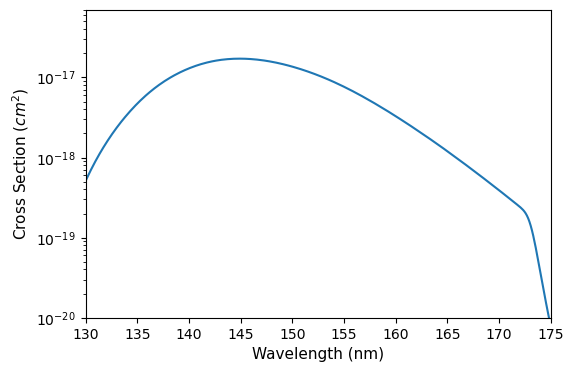

In [21]:
import duckdb

import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np   # (already imported earlier, but kept for completeness)
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
# Import both inset_axes and mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import pandas as pd
from multiprocessing import Pool, cpu_count
from functools import partial
import time


fig, ax = plt.subplots(figsize=(6, 4)) # This is the active line

ax.set_xlabel('Wavelength (nm)', fontsize=11)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=11)
# ax.set_title(f'Absorption Cross Section vs Wavelength (T = {T} K)') # Title is in the image, but not this code
ax.set_xlim(130, 175)
ax.set_ylim(1e-20, 0.7e-16)
ax.set_yscale('log')

# Plot model spectra for each alpha_D
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    ax.plot(1e7 / nu_range, cs, label=fr'Duo, $\alpha_D$ = {alpha_D} cm$^{{-1}}$', linestyle = "-")
    integrated_cs = np.trapz(cs, nu_range)
    print(f"Integrated cross-section for α_D={alpha_D}: {integrated_cs:.4e}")

# Validation data with error bars
ax.errorbar(validation_x, validation_y,
            yerr=0.3 * validation_y,
            fmt='o', markersize=4,markerfacecolor='none',
            color='black', label='Yoshino (2005)')
            
ax.plot(validation_x_2, validation_y_2,
            color='red', label='Exomol database', linestyle = "--")           

# Customize ticks
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(False)

# --- Set font size for legend ---
ax.legend(loc='lower left', fontsize=8
)


# ─────────────────────────────────────────────────────────────────
# --- NEW: Add Inset Plot (130-135 nm) ---
# ─────────────────────────────────────────────────────────────────

# 1. Define position: [x_start, y_start, width, height] in axes fraction
#    Placing it in the upper right, which is clear.
ax_inset = ax.inset_axes([0.25, 0.25, 0.23, 0.23])

# 2. Re-plot all data onto the inset
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    ax_inset.plot(1e7 / nu_range, cs, linestyle = "-")

ax_inset.errorbar(validation_x, validation_y,
                  yerr=0.3 * validation_y,
                  fmt='o', markersize=3, markerfacecolor='none', # smaller markers
                  color='black')
            
ax_inset.plot(validation_x_2, validation_y_2,
                  color='red', linestyle = "--")

# 3. Set the zoom limits for the inset
ax_inset.set_xlim(130, 135)
ax_inset.set_ylim(1e-19, 1e-16) # Zoom y-axis to the data in this region
ax_inset.set_yscale('log') # Match the main plot's y-scale

# 4. Style the inset (no labels, but with ticks)
ax_inset.set_xticklabels('')
ax_inset.set_yticklabels('')
ax_inset.tick_params(which='major', direction='in', top=True, right=True)
ax_inset.tick_params(which='minor', direction='in', top=True, right=True)
# Add a light grid to help guide the eye
ax_inset.grid(True, which='major', color='#DDDDDD', linestyle=':', linewidth=0.5)

# 5. Add connector lines to show where the zoom comes from
mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5")

# ─────────────────────────────────────────────────────────────────

# Use tight_layout to ensure labels don't overlap
plt.tight_layout()
# plt.savefig(f'o2_cross_section_comparison_T{T}_final.png', dpi=600)
plt.show()

In [24]:
# Compute continuum polarizabilities for all active A-E cases and write separate DBs.
# Physics/formulas are preserved from the original single-case loop used in the thesis.

import duckdb
import numpy as np
import pandas as pd
import time
from pathlib import Path

# Make this cell runnable even if only part of the notebook is executed.
try:
    active_cases
except NameError:
    case_ids = ['A', 'B', 'C', 'D', 'E']
    active_cases = case_ids.copy()

try:
    case_ids
except NameError:
    case_ids = list(active_cases)

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    case_pol_db_paths = {case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb' for case in case_ids}
    REFERENCE_POL_DB_PATH = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb')
    COMBINED_POL_DB_PATH = ABS_TEST_DIR / 'testcase_polarizabilities.duckdb'

results_by_case = {case: [] for case in active_cases}
cross_sections_by_case = {case: [] for case in active_cases}

# Convenience aliases for old downstream cells; case A remains the default single-case view.
results = results_by_case['A']
cross_sections = cross_sections_by_case['A']

start_time = time.time()

c = 2.99792458e10   # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K

T = 300
Q_300 = Q(T)

alpha_D_list = [160]
nu_range = np.linspace(1e7 / 200, 1e7 / 110, 50000)  # cm^-1
sensing_list = [1e7 / 632.8, 1e7 / 532.0, 1e7 / 400, 1e7 / 388, 1e7 / 300]  # cm^-1
POL_DB_MULTIPLIER = (1e30 * 3e8) / np.pi  # replaces the old one-time multiplier-update cell


def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks=4):
    """Wrapper around the existing optimized cross-section calculator."""
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions,
        intensities,
        nu_range,
        alpha_D_list,
        num_chunks,
        num_threads=None
    )
    return np.array(cross_section_list)


def get_polarizability(cross_section_list, nu_range, sensing_nu_list: list, gamma):
    """
    cross_section_list is in m^2/molecule, nu_range is in cm^-1,
    sensing_nu_list is in cm^-1, gamma is in cm^-1.
    """
    K = 1
    c_local = 2.99792458e10  # cm/s

    pol_list = []

    omega_sensing_list = [2 * np.pi * c_local * nu_sensing for nu_sensing in sensing_nu_list]
    gamma_omega = 2 * np.pi * c_local * gamma
    omega_range = 2 * np.pi * c_local * nu_range

    for omega_sensing in omega_sensing_list:
        denom = (
            (omega_range - omega_sensing - 1j * gamma_omega / 2)
            * (omega_range + omega_sensing + 1j * gamma_omega / 2)
        )
        denom = (
            (omega_range - omega_sensing )
            * (omega_range + omega_sensing)
        )
        integrand = cross_section_list / denom
        alpha_i = K * np.trapz(integrand, omega_range)
        pol_list.append(alpha_i)

    return pol_list


def _flatten_arraylike_value(x):
    """Convert array([z]) or [z] values to z; leave scalar values unchanged."""
    if isinstance(x, (np.ndarray, list, tuple)):
        return x[0] if len(x) > 0 else np.nan
    return x


def _prepare_cont_df_for_db(case, results_list):
    """Build the cont_polarizabilities table for one case."""
    cont_df = pd.DataFrame(results_list)

    if cont_df.empty:
        raise ValueError(f"No continuum polarizability rows computed for case {case}")

    if 'case' in cont_df.columns:
        cont_df['case'] = case
        ordered_cols = ['case'] + [col for col in cont_df.columns if col != 'case']
        cont_df = cont_df[ordered_cols]
    else:
        cont_df.insert(0, 'case', case)

    for col in cont_df.columns:
        cont_df[col] = cont_df[col].apply(_flatten_arraylike_value)

    # Split complex columns into real and imaginary components, and apply the same
    # continuum scaling that was previously done by the separate multiplier cell.
    pol_cols = [col for col in cont_df.columns if col.startswith('pol_') and col.endswith('nm')]

    for col in pol_cols:
        values = cont_df[col].astype(complex)
        cont_df[f'{col}_imag'] = values.apply(lambda x: x.imag * POL_DB_MULTIPLIER if pd.notnull(x) else 0.0)
        cont_df[col] = values.apply(lambda x: x.real * POL_DB_MULTIPLIER if pd.notnull(x) else 0.0)

    return cont_df


def _write_case_polarizability_db(case, results_list):
    """Write one self-contained A-E polarizability database."""
    output_path = Path(case_pol_db_paths[case])
    output_path.parent.mkdir(parents=True, exist_ok=True)

    cont_df = _prepare_cont_df_for_db(case, results_list)

    with duckdb.connect(str(output_path)) as con:
        con.register('cont_df', cont_df)
        con.execute("""
            CREATE OR REPLACE TABLE cont_polarizabilities AS
            SELECT * FROM cont_df
        """)

        # Copy the common discrete table into each output DB when available.
        # This keeps later SQL joins unchanged while varying only the continuum A-E data.
        if Path(REFERENCE_POL_DB_PATH).exists():
            ref_path_sql = str(REFERENCE_POL_DB_PATH).replace("'", "''")
            con.execute(f"ATTACH '{ref_path_sql}' AS ref_pol_db")
            con.execute("""
                CREATE OR REPLACE TABLE discrete_polarizabilities AS
                SELECT * FROM ref_pol_db.discrete_polarizabilities
            """)
            con.execute("DETACH ref_pol_db")
        else:
            print(f"WARNING: reference discrete DB not found: {REFERENCE_POL_DB_PATH}")
            print(f"         {output_path} contains cont_polarizabilities only.")

    return output_path, len(cont_df)


last_cross_section_byenergy_list = None

for case in active_cases:
    grouped = continuum_grouped_by_case[case]
    print(f"\n=== Case {case}: {len(grouped):,} lower-state groups ===")

    for row_number, (_, row) in enumerate(grouped.iterrows()):
        if row_number in (0, len(grouped) - 1):
            print("First/Last row")
            print(f"Starting computation with {len(row['A']):,} transitions")
            print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm^-1")
            print(f"Alpha_D values: {alpha_D_list}")

        down_v = row['down_v']
        down_J = row['down_J']
        down_lambda = row['down_lambda']
        down_sigma = row['down_sigma']
        down_omega = row['down_omega']
        down_energy = row['down_energy']

        A_list = np.array(row['A'])
        linepos_list = np.array(row['line_pos'])
        up_J = np.array(row['up_J'])

        not_an_intensity = (
            A_list * (2 * up_J + 1)
            / (8.0 * np.pi * c * linepos_list**2 * (2 * down_J + 1))
        )

        cross_section_byenergy_list = main(
            alpha_D_list,
            nu_range,
            linepos_list,
            not_an_intensity,
            num_chunks=1
        )
        last_cross_section_byenergy_list = cross_section_byenergy_list

        cross_section_byenergy_list_m2 = cross_section_byenergy_list * 1e-4
        alpha_i_list = get_polarizability(
            cross_section_byenergy_list_m2,
            nu_range,
            sensing_nu_list=sensing_list,
            gamma=4
        )

        result_entry = {
            'case': case,
            'down_v': down_v,
            'down_J': down_J,
            'down_lambda': down_lambda,
            'down_sigma': down_sigma,
            'down_omega': down_omega,
            'down_energy': down_energy,
        }

        cross_section_entry = {
            'case': case,
            'down_v': down_v,
            'down_J': down_J,
            'down_lambda': down_lambda,
            'down_sigma': down_sigma,
            'down_omega': down_omega,
            'down_energy': down_energy,
            'cross_section': cross_section_byenergy_list,
        }

        for wl_inv_cm, alpha_i in zip(sensing_list, alpha_i_list):
            wl_nm = 1e7 / wl_inv_cm
            result_entry[f'pol_{wl_nm:.1f}nm'] = alpha_i

        results_by_case[case].append(result_entry)
        cross_sections_by_case[case].append(cross_section_entry)

    db_path, n_rows = _write_case_polarizability_db(case, results_by_case[case])
    print(f"Wrote {n_rows:,} rows -> {db_path}")

# Backward-compatible aliases after computation.
results = results_by_case['A']
cross_sections = cross_sections_by_case['A']

total_time = time.time() - start_time
print(f"\nTotal A-E computation time: {total_time:.2f}s")
if last_cross_section_byenergy_list is not None:
    print(f"Last cross-section shapes: {[cs.shape for cs in last_cross_section_byenergy_list]}")



=== Case A: 3,845 lower-state groups ===
First/Last row
Starting computation with 992 transitions
Frequency range: 50000.0 to 90909.1 cm^-1
Alpha_D values: [160]
First/Last row
Starting computation with 3,450 transitions
Frequency range: 50000.0 to 90909.1 cm^-1
Alpha_D values: [160]
Wrote 3,845 rows -> /storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests/A_polarizabilities.duckdb

=== Case B: 3,845 lower-state groups ===
First/Last row
Starting computation with 976 transitions
Frequency range: 50000.0 to 90909.1 cm^-1
Alpha_D values: [160]
First/Last row
Starting computation with 3,414 transitions
Frequency range: 50000.0 to 90909.1 cm^-1
Alpha_D values: [160]
Wrote 3,845 rows -> /storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests/B_polarizabilities.duckdb

=== Case C: 3,845 lower-state groups ===
First/Last row
Starting computation with 971 transitions
Frequency range: 50000.0 to 90909.1 cm^-1
Alpha_D values: [160]
First/Last row
Starting computation w

In [23]:
results_by_case['A'][0:4]

[{'case': 'A',
  'down_v': 0,
  'down_J': 0.0,
  'down_lambda': 0.0,
  'down_sigma': 0.0,
  'down_omega': 0.0,
  'down_energy': 2.8652,
  'pol_632.8nm': array([1.69499341e-38+2.44389421e-43j]),
  'pol_532.0nm': array([1.73602824e-38+3.0511e-43j]),
  'pol_400.0nm': array([1.85384998e-38+4.63527024e-43j]),
  'pol_388.0nm': array([1.87222987e-38+4.87519151e-43j]),
  'pol_300.0nm': array([2.11091458e-38+8.04641374e-43j])},
 {'case': 'A',
  'down_v': 0,
  'down_J': 1.0,
  'down_lambda': 0.0,
  'down_sigma': 1.0,
  'down_omega': 1.0,
  'down_energy': 2.8652,
  'pol_632.8nm': array([1.69499341e-38+2.44389421e-43j]),
  'pol_532.0nm': array([1.73602824e-38+3.0511e-43j]),
  'pol_400.0nm': array([1.85384998e-38+4.63527024e-43j]),
  'pol_388.0nm': array([1.87222987e-38+4.8751915e-43j]),
  'pol_300.0nm': array([2.11091458e-38+8.04641374e-43j])},
 {'case': 'A',
  'down_v': 0,
  'down_J': 2.0,
  'down_lambda': 0.0,
  'down_sigma': 0.0,
  'down_omega': 0.0,
  'down_energy': 17.1904,
  'pol_632.8nm': a

In [56]:
# cross_sections[0:4]
# import pandas as pd
# import numpy as np

# # Assuming 'cross_sections_list' is your list of dictionaries
# df_cs = pd.DataFrame(cross_sections)

# # 1. Convert arrays to standard lists for safe Parquet serialization
# df_cs['cross_section'] = df_cs['cross_section'].apply(lambda x: np.array(x).flatten().tolist())

# # 2. Write to Parquet (Requires 'pyarrow' installed: pip install pyarrow)
# file_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/cross_sections.parquet'
# df_cs.to_parquet(file_path, engine='pyarrow')
# print("Successfully saved to Parquet.")

# # ---------------------------------------------------------


Successfully saved to Parquet.


TypeError: 'Axes' object is not subscriptable

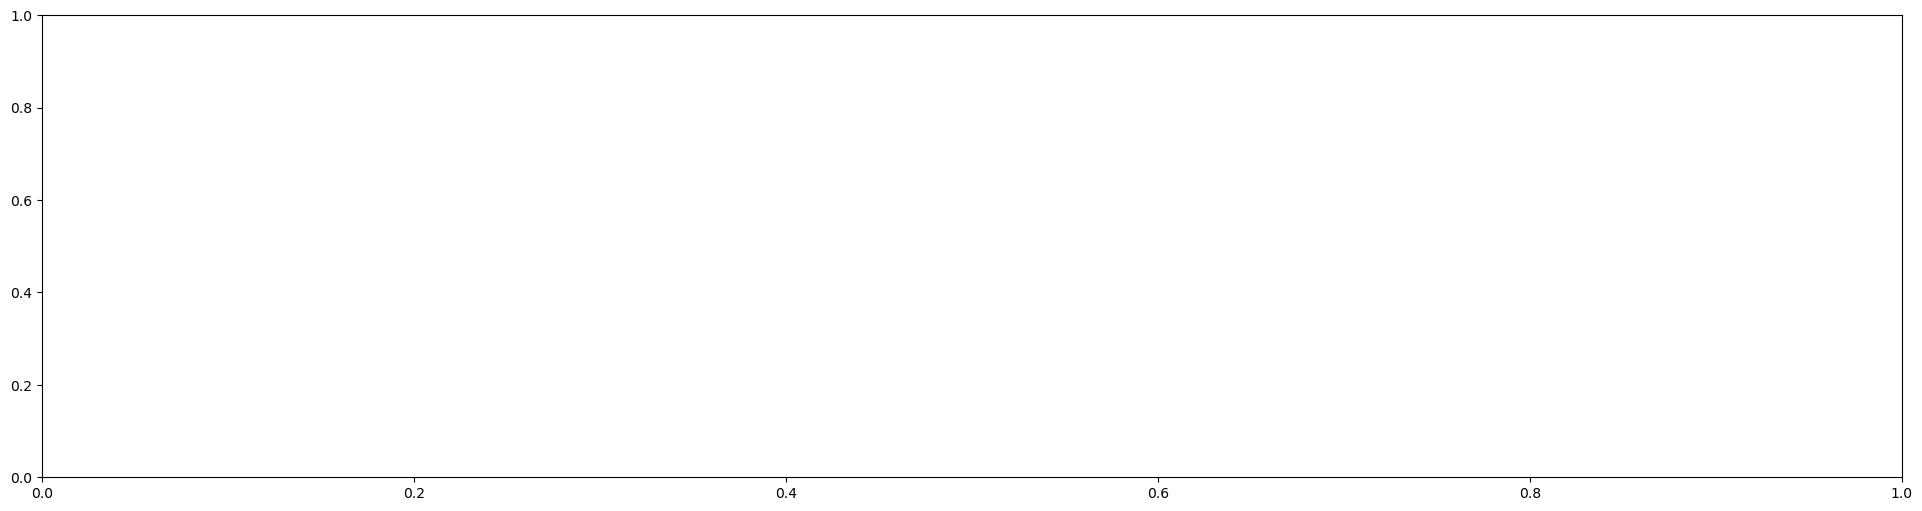

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D

try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_FIGURE_DIR
except NameError:
    ABS_FIGURE_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests/figures')
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MULTIPLIER = (1e30 * 3e8) / np.pi

wavelength_keys = ['pol_632.8nm', 'pol_532.0nm', 'pol_400.0nm', 'pol_388.0nm']
wavelength_keys = ['pol_632.8nm', 'pol_532.0nm', 'pol_400.0nm', 'pol_388.0nm']

target_Js = [10, 30]

# Per instruction: J=10 red, J=30 blue. Cases are distinguished by markers/linestyles.
j_colors = {10: 'red', 30: 'blue'}
case_linestyles = {
    'A': '-',
    'B': '--',
    'C': '-.',
    'D': ':',
    'E': (0, (3, 1, 1, 1)),
}
case_markers = {
    'A': 'o',
    'B': 's',
    'C': '^',
    'D': 'D',
    'E': 'v',
}


def _alpha_real_from_result(result_entry, pol_key):
    value = result_entry[pol_key]
    if isinstance(value, (np.ndarray, list, tuple)):
        value = value[0]
    return (value * MULTIPLIER).real


fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=False)

for i, pol_key in enumerate(wavelength_keys):
    ax = axes[i]

    for case in active_cases:
        for target_J in target_Js:
            v_list = []
            alpha_list = []

            for r in results_by_case[case]:
                if np.isclose(r['down_J'], target_J):
                    v_list.append(r['down_v'])
                    alpha_list.append(_alpha_real_from_result(r, pol_key))

            if v_list:
                order = np.argsort(v_list)
                v_arr = np.array(v_list)[order]
                alpha_arr = np.array(alpha_list)[order]

                ax.plot(
                    v_arr,
                    alpha_arr,
                    color=j_colors[target_J],
                    linestyle=case_linestyles.get(case, '-'),
                    marker=case_markers.get(case, 'o'),
                    linewidth=1.3,
                    markersize=4,
                    alpha=0.9,
                    label=f'Case {case}, J={target_J}'
                )

    wv_label = pol_key.replace('pol_', '')
    ax.set_title(fr'Polarizability at $\lambda = {wv_label}$', fontsize=14)
    ax.set_xlabel(r"Vibrational Quantum Number ($v''$)", fontsize=12)

    if i == 0:
        ax.set_ylabel(r'Continuum Polarizability $\alpha$ [$\AA^3$]', fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.6, which='major')
    ax.minorticks_on()

# Compact, non-repeated legends: color = J, linestyle/marker = case.
j_handles = [
    Line2D([0], [0], color=j_colors[J], lw=2, label=f"J'' = {J}")
    for J in target_Js
]
case_handles = [
    Line2D(
        [0], [0],
        color='black',
        linestyle=case_linestyles.get(case, '-'),
        marker=case_markers.get(case, 'o'),
        lw=1.5,
        label=f'Case {case}'
    )
    for case in active_cases
]

axes[-1].legend(handles=j_handles + case_handles, frameon=True, fontsize=8, loc='best')

plt.suptitle("A-E Continuum Polarizability vs. Vibrational Level", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'AE_continuum_polarizability_vs_v_J10_J30.pdf', dpi=400)
plt.show()


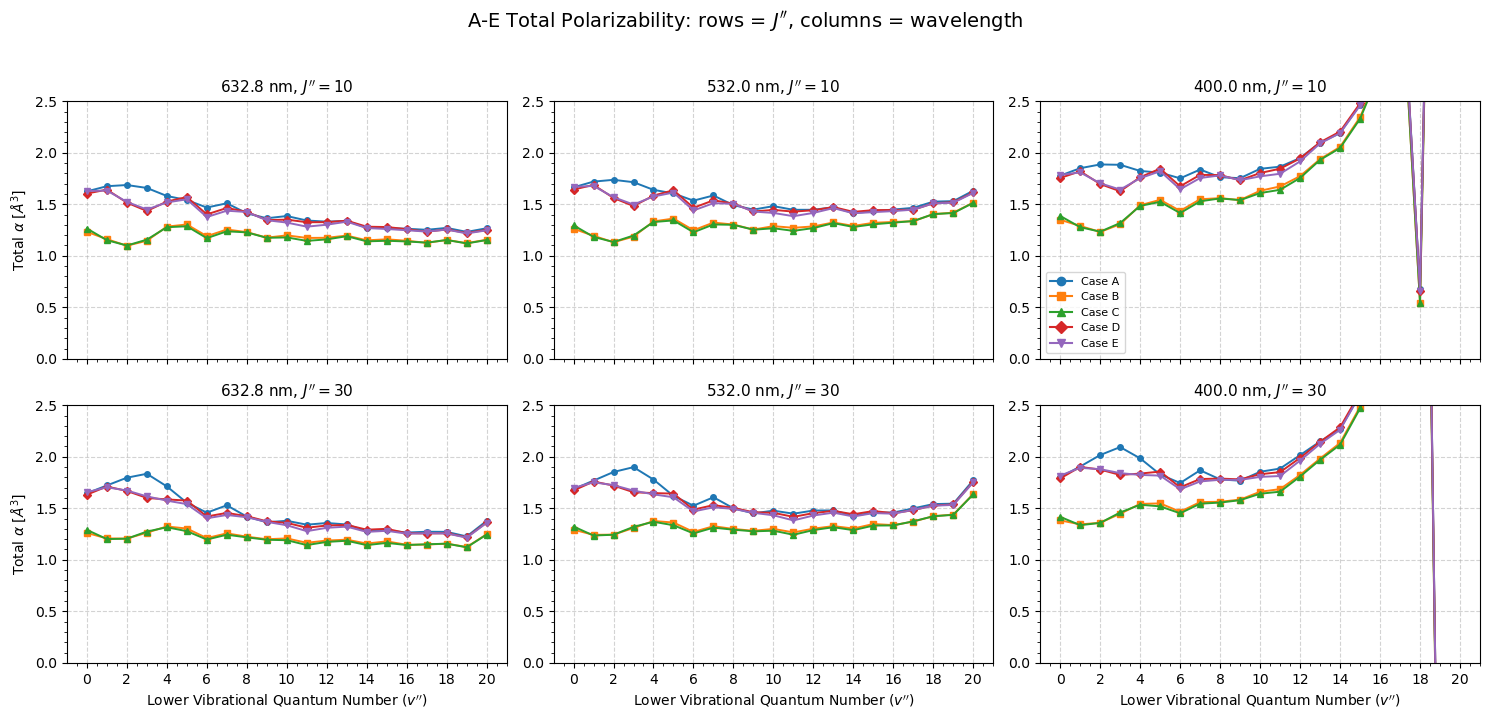

In [25]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    case_pol_db_paths = {case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb' for case in active_cases}

MAX_V = 20
J_VALUES = [10, 30]
WAVELENGTH_CONFIG = [
    ('pol_632.8nm', '632.8 nm'),
    ('pol_532.0nm', '532.0 nm'),
    ('pol_400.0nm', '400.0 nm'),
]

FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

case_colors = {
    'A': '#1f77b4',
    'B': '#ff7f0e',
    'C': '#2ca02c',
    'D': '#d62728',
    'E': '#9467bd',
}
case_markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D', 'E': 'v'}


def _load_total_pol_for_case(case, wavelength_col, j_values, max_v):
    wl_sql = f'"{wavelength_col}"'
    query = f"""
    SELECT
        c.down_v,
        c.down_J,
        COALESCE(c.{wl_sql}, 0) AS pol_cont,
        COALESCE(d.{wl_sql}, 0) AS pol_disc,
        (COALESCE(c.{wl_sql}, 0) + COALESCE(d.{wl_sql}, 0)) AS pol_total
    FROM cont_polarizabilities c
    JOIN discrete_polarizabilities d
      ON c.down_v = d.down_v
     AND c.down_J = d.down_J
     AND c.down_omega = d.down_omega
     AND c.down_lambda = d.down_lambda
     AND c.down_sigma = d.down_sigma
    WHERE c.down_J IN ({','.join(map(str, j_values))})
      AND c.down_v <= {max_v}
      AND c.down_omega = {FIXED_OMEGA}
      AND c.down_lambda = {FIXED_LAMBDA}
      AND c.down_sigma = {FIXED_SIGMA}
    ORDER BY c.down_J, c.down_v
    """
    with duckdb.connect(str(case_pol_db_paths[case])) as con:
        df = con.execute(query).df()
    df['case'] = case
    return df


fig, axes = plt.subplots(len(J_VALUES), len(WAVELENGTH_CONFIG), figsize=(15, 7), sharex=True, sharey=False)

for row_idx, j_val in enumerate(J_VALUES):
    for col_idx, (wavelength_col, wavelength_label) in enumerate(WAVELENGTH_CONFIG):
        ax = axes[row_idx, col_idx]

        for case in active_cases:
            df_case = _load_total_pol_for_case(case, wavelength_col, J_VALUES, MAX_V)
            subset = df_case[df_case['down_J'] == j_val].sort_values('down_v')

            ax.plot(
                subset['down_v'],
                subset['pol_total'],
                color=case_colors.get(case),
                marker=case_markers.get(case, 'o'),
                linestyle='-',
                linewidth=1.4,
                markersize=4,
                label=f'Case {case}'
            )

        ax.set_title(fr"{wavelength_label}, $J''={j_val}$", fontsize=11)
        ax.set_xticks(range(0, MAX_V + 1, 2))
        ax.grid(True, linestyle='--', alpha=0.55)
        ax.minorticks_on()
        ax.set_ylim(0, 2.5)

        if row_idx == len(J_VALUES) - 1:
            ax.set_xlabel(r"Lower Vibrational Quantum Number ($v''$)")
        if col_idx == 0:
            ax.set_ylabel(r"Total $\alpha$ [$\AA^3$]")

handles = [
    Line2D([0], [0], color=case_colors.get(case), marker=case_markers.get(case, 'o'),
           linestyle='-', lw=1.5, label=f'Case {case}')
    for case in active_cases
]
axes[0, -1].legend(handles=handles, frameon=True, fontsize=8, loc='best')

plt.suptitle(r"A-E Total Polarizability: rows = $J''$, columns = wavelength", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'AE_total_polarizability_J10_J30_by_wavelength.pdf', dpi=400)
plt.show()


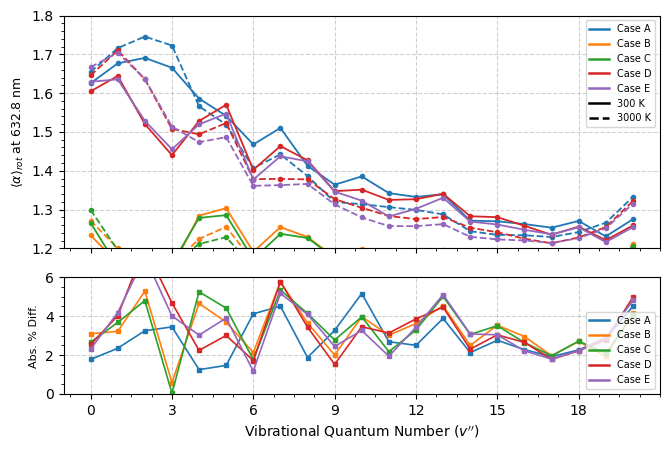

In [26]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    case_pol_db_paths = {case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb' for case in active_cases}

c = 2.99792458e10
h = 6.62607015e-34
k_B = 1.380649e-23

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125
TARGET_TEMPS = [300, 3000]
TARGET_WAVELENGTH = 'pol_632.8nm'
DF_COL_NAME = 'pol_632_8nm'

FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

case_colors = {
    'A': '#1f77b4',
    'B': '#ff7f0e',
    'C': '#2ca02c',
    'D': '#d62728',
    'E': '#9467bd',
}
temp_linestyles = {300: '-', 3000: '--'}


def _load_rot_avg_input(case):
    wl_sql = f'"{TARGET_WAVELENGTH}"'
    query = f"""
    SELECT
        c.down_v,
        c.down_J,
        c.down_energy,
        (COALESCE(c.{wl_sql}, 0) + COALESCE(d.{wl_sql}, 0)) AS {DF_COL_NAME}
    FROM cont_polarizabilities c
    JOIN discrete_polarizabilities d
      ON c.down_v = d.down_v
     AND c.down_J = d.down_J
     AND c.down_omega = d.down_omega
     AND c.down_lambda = d.down_lambda
     AND c.down_sigma = d.down_sigma
    WHERE c.down_v <= {MAX_V}
      AND c.down_J <= {MAX_J}
      AND c.down_omega = {FIXED_OMEGA}
      AND c.down_lambda = {FIXED_LAMBDA}
      AND c.down_sigma = {FIXED_SIGMA}
    ORDER BY c.down_v, c.down_J
    """
    with duckdb.connect(str(case_pol_db_paths[case])) as con:
        df = con.execute(query).df()
    df['case'] = case
    df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY
    return df


fig, axes = plt.subplots(2, 1, figsize=(6.8, 4.6), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
avg_pol_results = {}

for case in active_cases:
    df = _load_rot_avg_input(case)
    avg_pol_results[case] = {}

    for T in TARGET_TEMPS:
        df_T = df.copy()
        exponent = (-h * c * df_T['delta_E']) / (k_B * T)
        df_T['weight'] = (2 * df_T['down_J'] + 1) * np.exp(exponent)
        df_T['weighted_pol'] = df_T['weight'] * df_T[DF_COL_NAME]

        grouped = df_T.groupby('down_v').agg(
            sum_weighted_pol=('weighted_pol', 'sum'),
            sum_weights=('weight', 'sum')
        ).reset_index()

        grouped['avg_pol'] = np.where(
            grouped['sum_weights'] > 0,
            grouped['sum_weighted_pol'] / grouped['sum_weights'],
            0.0
        )

        avg_pol_results[case][T] = grouped[['down_v', 'avg_pol']].copy()

        axes[0].plot(
            grouped['down_v'],
            grouped['avg_pol'],
            color=case_colors.get(case),
            linestyle=temp_linestyles[T],
            marker='o',
            markersize=3,
            linewidth=1.3,
            label=f'Case {case}, T={T} K'
        )

    merged = avg_pol_results[case][300].merge(
        avg_pol_results[case][3000],
        on='down_v',
        suffixes=('_300K', '_3000K')
    )
    merged['abs_diff_pct'] = (
        np.abs(merged['avg_pol_3000K'] - merged['avg_pol_300K'])
        / np.abs(merged['avg_pol_300K'])
        * 100
    )

    axes[1].plot(
        merged['down_v'],
        merged['abs_diff_pct'],
        color=case_colors.get(case),
        linestyle='-',
        marker='s',
        markersize=3,
        linewidth=1.2,
        label=f'Case {case}'
    )

axes[0].set_ylabel(r"$\langle\alpha\rangle_{rot}$ at 632.8 nm", fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim(1.2, 1.8)
axes[0].minorticks_on()

axes[1].set_ylabel("Abs. % Diff.", fontsize=8)
axes[1].set_xlabel(r"Vibrational Quantum Number ($v''$)", fontsize=10)
axes[1].set_xticks(range(0, MAX_V + 1, 3))
axes[1].set_ylim(0, 6)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].minorticks_on()

case_handles = [
    Line2D([0], [0], color=case_colors.get(case), lw=1.8, label=f'Case {case}')
    for case in active_cases
]
temp_handles = [
    Line2D([0], [0], color='black', linestyle=temp_linestyles[T], lw=1.8, label=f'{T} K')
    for T in TARGET_TEMPS
]
axes[0].legend(handles=case_handles + temp_handles, frameon=True, fontsize=7, loc='best')
axes[1].legend(handles=case_handles, frameon=True, fontsize=7, loc='best')

plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'AE_rotationally_averaged_pol_632_8nm.pdf', dpi=500)
plt.show()


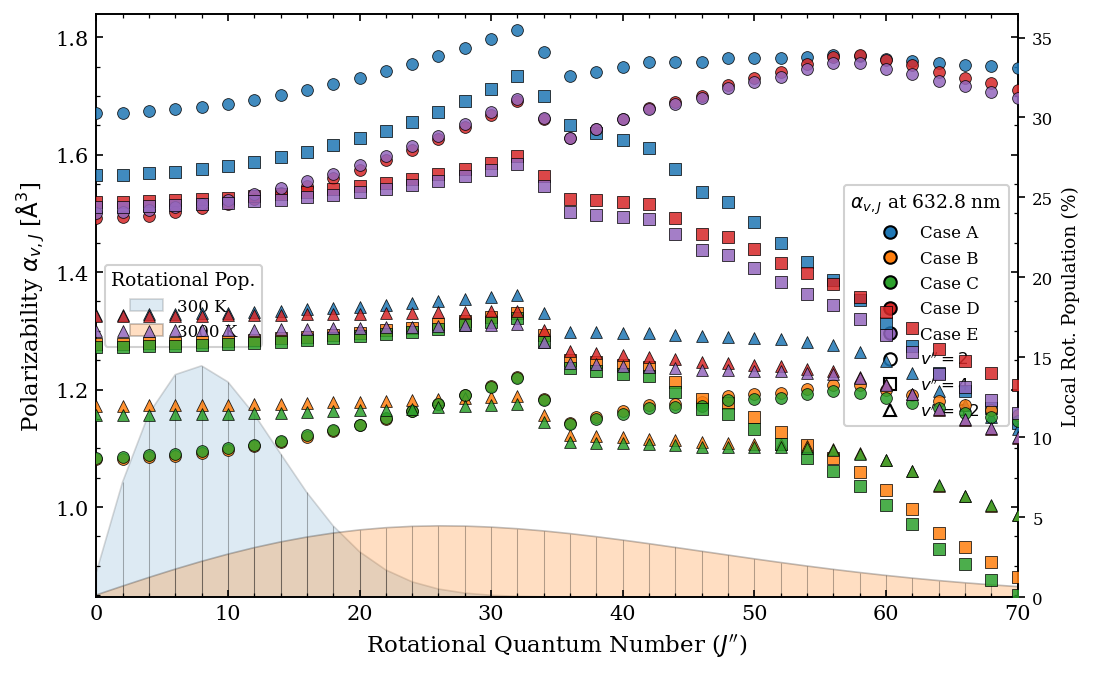

In [29]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "figure.dpi": 150,
    "grid.alpha": 0.2,
    "legend.frameon": True,
    "legend.fontsize": 8
})

try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    case_pol_db_paths = {case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb' for case in active_cases}

c, h, k_B = 2.99792458e10, 6.62607015e-34, 1.380649e-23
MAX_V, MAX_J, MAX_J_PLOT = 20, 125, 70
TARGET_TEMPS = [300, 3000]
TARGET_WL = 'pol_632.8nm'
TARGET_V = [2, 4, 12]
POP_REF_V = 2

FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

case_colors = {
    'A': '#1f77b4',
    'B': '#ff7f0e',
    'C': '#2ca02c',
    'D': '#d62728',
    'E': '#9467bd',
}
v_markers = {2: 'o', 4: 's', 12: '^'}
temp_shade_colors = {300: '#1f77b4', 3000: '#ff7f0e'}


def _load_alpha_vs_J(case):
    wl_sql = f'"{TARGET_WL}"'
    query = f"""
    SELECT
        c.down_v,
        c.down_J,
        c.down_energy,
        (COALESCE(c.{wl_sql}, 0) + COALESCE(d.{wl_sql}, 0)) AS total_alpha
    FROM cont_polarizabilities c
    JOIN discrete_polarizabilities d
      ON c.down_v = d.down_v
     AND c.down_J = d.down_J
     AND c.down_omega = d.down_omega
     AND c.down_lambda = d.down_lambda
     AND c.down_sigma = d.down_sigma
    WHERE c.down_v <= {MAX_V}
      AND c.down_J <= {MAX_J}
      AND c.down_omega = {FIXED_OMEGA}
      AND c.down_lambda = {FIXED_LAMBDA}
      AND c.down_sigma = {FIXED_SIGMA}
    ORDER BY c.down_v, c.down_J
    """
    with duckdb.connect(str(case_pol_db_paths[case])) as con:
        df = con.execute(query).df()
    df['case'] = case
    return df


df_by_case = {case: _load_alpha_vs_J(case) for case in active_cases}

# One population background only, using case A/reference geometry.
population_case = 'A' if 'A' in active_cases else active_cases[0]
df_pop = df_by_case[population_case].copy()

df_pop['E_v0'] = df_pop.groupby('down_v')['down_energy'].transform('min')
df_pop['E_rot_local'] = df_pop['down_energy'] - df_pop['E_v0']

for T in TARGET_TEMPS:
    exponent = (-h * c * df_pop['E_rot_local']) / (k_B * T)
    df_pop[f'weight_{T}K'] = (2 * df_pop['down_J'] + 1) * np.exp(exponent)
    group_sum = df_pop.groupby('down_v')[f'weight_{T}K'].transform('sum')
    df_pop[f'pop_local_{T}K'] = (df_pop[f'weight_{T}K'] / group_sum) * 100.0

fig, ax_alpha = plt.subplots(figsize=(7.4, 4.6))
ax_pop = ax_alpha.twinx()

# Population background from one reference population.
vd_pop = df_pop[df_pop['down_v'] == POP_REF_V]
for T in TARGET_TEMPS:
    J = vd_pop['down_J'].values
    pop = vd_pop[f'pop_local_{T}K'].values

    is_hot = (T == 3000)
    alpha_val = 0.25 if is_hot else 0.15
    shade_color = temp_shade_colors.get(T, 'gray')

    ax_pop.fill_between(
        J, 0, pop,
        color=shade_color,
        alpha=alpha_val,
        edgecolor='black',
        linewidth=0.8,
        linestyle='solid'
    )
    ax_pop.vlines(J, 0, pop, color='black', linewidth=0.5, alpha=0.3)

# Polarizability curves: case=color, v=marker.
for case in active_cases:
    df_case_plot = df_by_case[case][
        df_by_case[case]['down_v'].isin(TARGET_V)
        & (df_by_case[case]['down_J'] <= MAX_J_PLOT)
    ].copy()

    for v_val in TARGET_V:
        vd = (
            df_case_plot[df_case_plot['down_v'] == v_val]
            .drop_duplicates(subset=['down_J'], keep='first')
            .sort_values('down_J')
        )

        ax_alpha.scatter(
            vd['down_J'],
            vd['total_alpha'],
            color=case_colors.get(case),
            marker=v_markers.get(v_val, 'o'),
            edgecolor='black',
            linewidth=0.4,
            s=32,
            alpha=0.85,
            zorder=20
        )

ax_alpha.set_xlim(0, MAX_J_PLOT)

all_plot_values = pd.concat([
    df_by_case[case][
        df_by_case[case]['down_v'].isin(TARGET_V)
        & (df_by_case[case]['down_J'] <= MAX_J_PLOT)
    ]['total_alpha']
    for case in active_cases
])
ax_alpha.set_ylim(all_plot_values.min() * 0.995, all_plot_values.max() * 1.015)

ax_alpha.set_xlabel(r"Rotational Quantum Number ($J''$)", fontsize=11)
ax_alpha.set_ylabel(r"Polarizability $\alpha_{v,J}$ [$\mathrm{\AA}^3$]", fontsize=11)

ax_alpha.set_zorder(ax_pop.get_zorder() + 1)
ax_alpha.patch.set_visible(False)

ax_pop.set_ylim(0, df_pop[f'pop_local_300K'].max() * 2.5)
ax_pop.set_ylabel("Local Rot. Population (%)", fontsize=9, color='black')
ax_pop.tick_params(axis='y', colors='black', labelsize=8)

ax_alpha.xaxis.set_minor_locator(AutoMinorLocator())
ax_alpha.yaxis.set_minor_locator(AutoMinorLocator())
ax_alpha.tick_params(which='both', direction='in', top=True, right=True)
ax_alpha.grid(False)

case_handles = [
    Line2D([0], [0], color=case_colors.get(case), marker='o', linestyle='None',
           markeredgecolor='black', label=f'Case {case}')
    for case in active_cases
]
v_handles = [
    Line2D([0], [0], color='black', marker=v_markers.get(v), linestyle='None',
           markerfacecolor='white', label=rf"$v''={v}$")
    for v in TARGET_V
]
pop_handles = [
    mpatches.Patch(facecolor=temp_shade_colors[300], edgecolor='black', linewidth=0.8, alpha=0.15, label="300 K"),
    mpatches.Patch(facecolor=temp_shade_colors[3000], edgecolor='black', linewidth=0.8, alpha=0.25, label="3000 K"),
]

leg1 = ax_alpha.legend(handles=case_handles + v_handles, loc='center right',
                       title=r"$\alpha_{v,J}$ at 632.8 nm", title_fontsize=9, framealpha=0.9)
ax_alpha.add_artist(leg1)
ax_alpha.legend(handles=pop_handles, loc='center left', title="Rotational Pop.",
                title_fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'AE_alpha_vs_J_single_population.pdf', dpi=400)
plt.show()


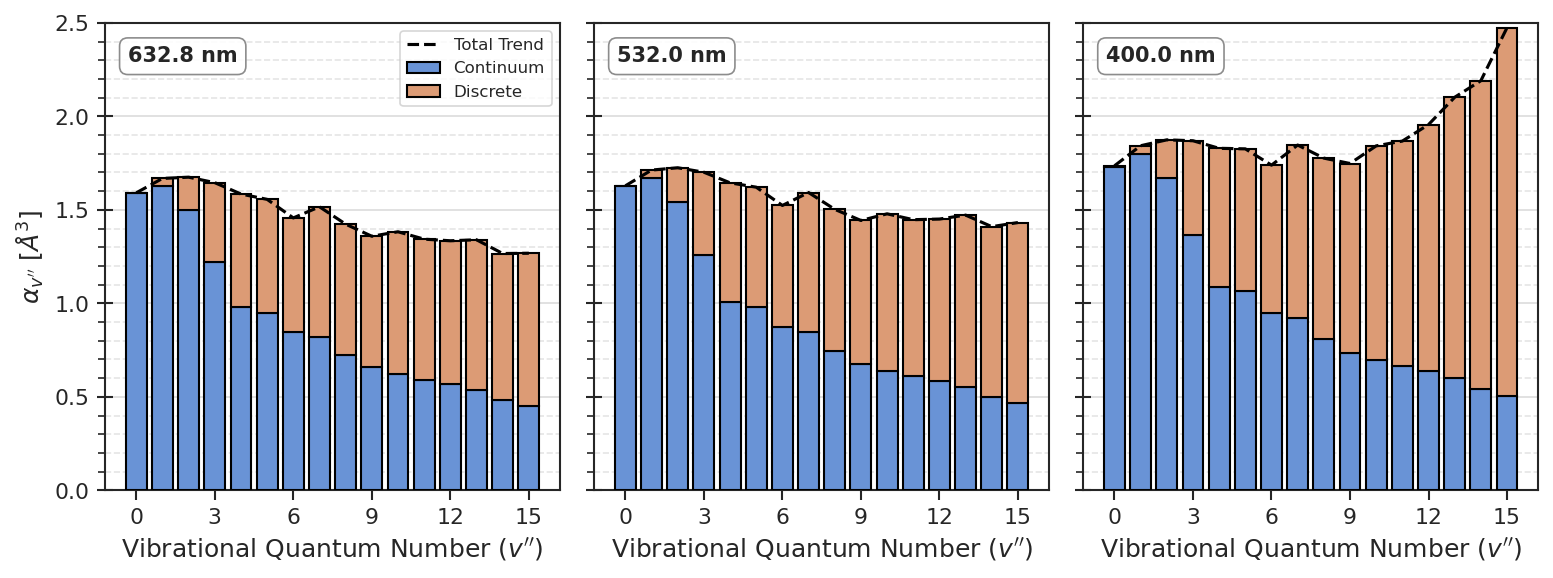

In [76]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    case_pol_db_paths = {case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb' for case in active_cases}

c = 2.99792458e10
h = 6.62607015e-34
k_B = 1.380649e-23

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 15
MAX_J = 125
T_ROT = 300

FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

wavelengths = ['400_0nm', '532_0nm', '632_8nm']
plot_config = [
    ('632_8nm', '632.8 nm'),
    ('532_0nm', '532.0 nm'),
    ('400_0nm', '400.0 nm'),
]

case_colors = {
    'A': '#1f77b4',
    'B': '#ff7f0e',
    'C': '#2ca02c',
    'D': '#d62728',
    'E': '#9467bd',
}
case_markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D', 'E': 'v'}

cont_color = "#6993D6"
disc_color = "#DC9B75"
reference_case_for_bars = 'A' if 'A' in active_cases else active_cases[0]


def _load_bar_input(case):
    query = f"""
    SELECT
        c.down_v,
        c.down_J,
        c.down_energy,
        COALESCE(c."pol_400.0nm", 0) AS cont_400_0nm,
        COALESCE(d."pol_400.0nm", 0) AS disc_400_0nm,
        COALESCE(c."pol_532.0nm", 0) AS cont_532_0nm,
        COALESCE(d."pol_532.0nm", 0) AS disc_532_0nm,
        COALESCE(c."pol_632.8nm", 0) AS cont_632_8nm,
        COALESCE(d."pol_632.8nm", 0) AS disc_632_8nm
    FROM cont_polarizabilities c
    JOIN discrete_polarizabilities d
      ON c.down_v = d.down_v
     AND c.down_J = d.down_J
     AND c.down_omega = d.down_omega
     AND c.down_lambda = d.down_lambda
     AND c.down_sigma = d.down_sigma
    WHERE c.down_v <= {MAX_V}
      AND c.down_J <= {MAX_J}
      AND c.down_omega = {FIXED_OMEGA}
      AND c.down_lambda = {FIXED_LAMBDA}
      AND c.down_sigma = {FIXED_SIGMA}
    ORDER BY c.down_v, c.down_J
    """
    with duckdb.connect(str(case_pol_db_paths[case])) as con:
        df = con.execute(query).df()
    df['case'] = case
    df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY
    return df


def _rotational_average_components(df):
    df = df.copy()
    exponent = (-h * c * df['delta_E']) / (k_B * T_ROT)
    df['weight'] = (2 * df['down_J'] + 1) * np.exp(exponent)

    agg_dict = {'weight': 'sum'}
    for wl in wavelengths:
        df[f'w_cont_{wl}'] = df['weight'] * df[f'cont_{wl}']
        df[f'w_disc_{wl}'] = df['weight'] * df[f'disc_{wl}']
        agg_dict[f'w_cont_{wl}'] = 'sum'
        agg_dict[f'w_disc_{wl}'] = 'sum'

    grouped = df.groupby('down_v').agg(agg_dict).reset_index()

    for wl in wavelengths:
        grouped[f'avg_cont_{wl}'] = np.where(grouped['weight'] > 0, grouped[f'w_cont_{wl}'] / grouped['weight'], 0.0)
        grouped[f'avg_disc_{wl}'] = np.where(grouped['weight'] > 0, grouped[f'w_disc_{wl}'] / grouped['weight'], 0.0)
        grouped[f'avg_total_{wl}'] = grouped[f'avg_cont_{wl}'] + grouped[f'avg_disc_{wl}']

    return grouped


grouped_by_case = {
    case: _rotational_average_components(_load_bar_input(case))
    for case in active_cases
}

fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2), sharey=True)

for i, (col_key, label) in enumerate(plot_config):
    ax = axes[i]
    ax2 = ax.twinx()

    grouped_ref = grouped_by_case[reference_case_for_bars]
    v_levels = grouped_ref['down_v']
    cont_vals = grouped_ref[f'avg_cont_{col_key}']
    disc_vals = grouped_ref[f'avg_disc_{col_key}']

    # Original stacked-bar decomposition is preserved for the reference case.
    ax.bar(v_levels, cont_vals, label=f'Continuum, Case {reference_case_for_bars}',
           color=cont_color, edgecolor='black', linewidth=1, zorder=3)
    ax.bar(v_levels, disc_vals, bottom=cont_vals, label='Discrete',
           color=disc_color, edgecolor='black', linewidth=1, zorder=3)

    # Secondary y-axis: A-E total curves.
    for case in active_cases:
        grouped_case = grouped_by_case[case]
        ax2.plot(
            grouped_case['down_v'],
            grouped_case[f'avg_total_{col_key}'],
            color=case_colors.get(case),
            marker=case_markers.get(case, 'o'),
            linestyle='-',
            linewidth=1.4,
            markersize=3.5,
            label=f'Case {case} total',
            zorder=5
        )

    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=10, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9), zorder=6)

    ax.set_xlabel(r"Vibrational Quantum Number ($v''$)", fontsize=11)
    ax.set_xticks(range(0, MAX_V + 1, 3))
    ax.set_ylim(0, 2.5)
    ax2.set_ylim(0, 2.5)

    ax.minorticks_on()
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='major', direction='inout', length=8, width=1)
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.7, zorder=0)
    ax.grid(True, which='minor', axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax.grid(False, axis='x')

    if i == 0:
        ax.set_ylabel(rf"Case {reference_case_for_bars} stacked $\alpha_{{v''}}$ [$\AA^3$]", fontsize=10)
        ax.legend(frameon=True, loc='upper left', fontsize=7)
    if i == 2:
        ax2.set_ylabel(r"A-E total $\alpha_{v''}$ [$\AA^3$]", fontsize=10)

case_handles = [
    Line2D([0], [0], color=case_colors.get(case), marker=case_markers.get(case, 'o'),
           linestyle='-', lw=1.5, label=f'Case {case} total')
    for case in active_cases
]
axes[-1].legend(handles=case_handles, frameon=True, loc='lower right', fontsize=7)

plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'AE_discrete_continuum_stacked_with_secondary_total.pdf', dpi=400)
plt.show()


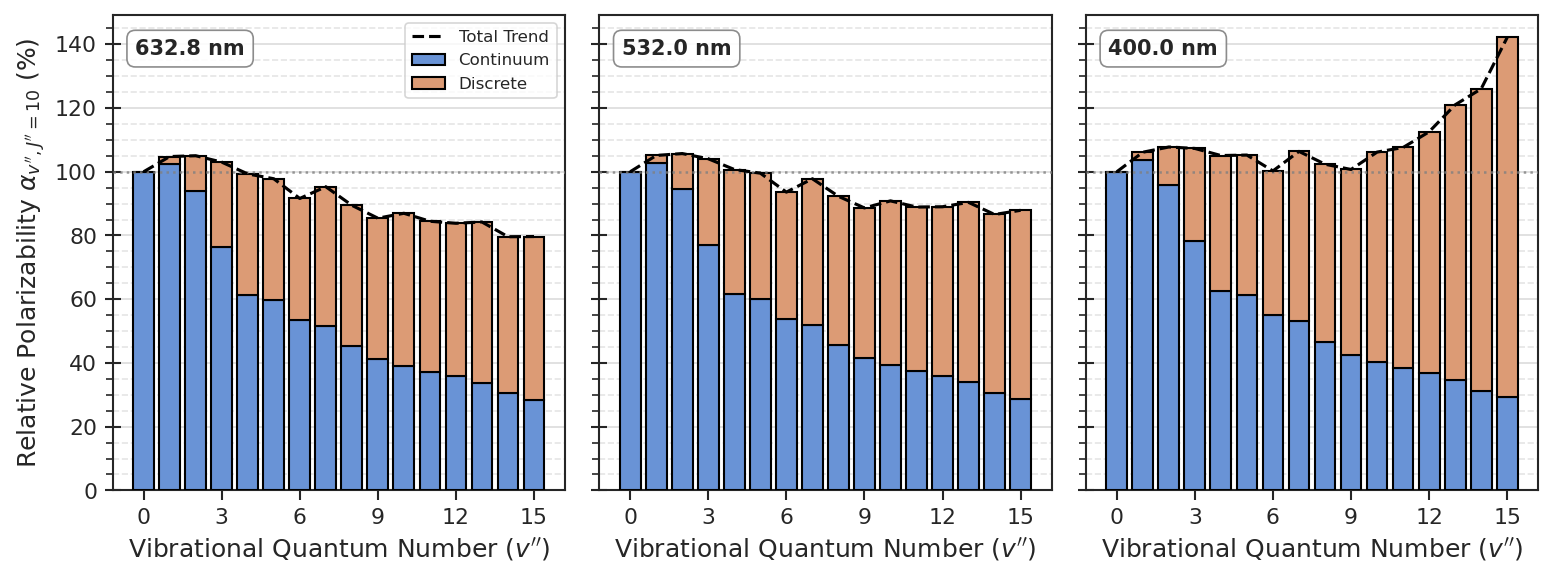

In [56]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Per instruction: compare two datasets only. Case 1 = A, case 5 = E.
comparison_cases = ['A', 'E']

try:
    case_pol_db_paths
except NameError:
    case_pol_db_paths = {
        case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb'
        for case in ['A', 'B', 'C', 'D', 'E']
    }

comparison_case_pol_db_paths = {
    case: Path(case_pol_db_paths.get(case, ABS_TEST_DIR / f'{case}_polarizabilities.duckdb'))
    for case in comparison_cases
}

MAX_V = 15
FIXED_J = 10

FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

wavelengths = ['400_0nm', '532_0nm', '632_8nm']
plot_config = [
    ('632_8nm', '632.8 nm'),
    ('532_0nm', '532.0 nm'),
    ('400_0nm', '400.0 nm'),
]

case_colors = {
    'A': '#1f77b4',
    'E': '#9467bd',
}
case_markers = {'A': 'o', 'E': 'v'}


def _load_fixed_J_percentages(case):
    query = f"""
    SELECT
        c.down_v,
        c.down_J,
        COALESCE(c."pol_400.0nm", 0) AS cont_400_0nm,
        COALESCE(d."pol_400.0nm", 0) AS disc_400_0nm,
        COALESCE(c."pol_532.0nm", 0) AS cont_532_0nm,
        COALESCE(d."pol_532.0nm", 0) AS disc_532_0nm,
        COALESCE(c."pol_632.8nm", 0) AS cont_632_8nm,
        COALESCE(d."pol_632.8nm", 0) AS disc_632_8nm
    FROM cont_polarizabilities c
    JOIN discrete_polarizabilities d
      ON c.down_v = d.down_v
     AND c.down_J = d.down_J
     AND c.down_omega = d.down_omega
     AND c.down_lambda = d.down_lambda
     AND c.down_sigma = d.down_sigma
    WHERE c.down_v <= {MAX_V}
      AND c.down_J = {FIXED_J}
      AND c.down_omega = {FIXED_OMEGA}
      AND c.down_lambda = {FIXED_LAMBDA}
      AND c.down_sigma = {FIXED_SIGMA}
    ORDER BY c.down_v
    """
    with duckdb.connect(str(comparison_case_pol_db_paths[case])) as con:
        df = con.execute(query).df()

    df['case'] = case

    for wl in wavelengths:
        total_pol = df[f'cont_{wl}'] + df[f'disc_{wl}']
        v0_values = total_pol[df['down_v'] == 0].values
        if len(v0_values) == 0 or np.isclose(v0_values[0], 0):
            raise ValueError(f"Cannot normalize case {case}, {wl}: missing/zero v=0 value")

        v0_total = v0_values[0]
        df[f'pct_total_{wl}'] = (total_pol / v0_total) * 100.0
        df[f'pct_cont_{wl}'] = (df[f'cont_{wl}'] / v0_total) * 100.0
        df[f'pct_disc_{wl}'] = (df[f'disc_{wl}'] / v0_total) * 100.0

    return df


df_by_case = {
    case: _load_fixed_J_percentages(case)
    for case in comparison_cases
}

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4), sharey=True)

for i, (col_key, label) in enumerate(plot_config):
    ax = axes[i]

    for case in comparison_cases:
        df_case = df_by_case[case]

        ax.plot(
            df_case['down_v'],
            df_case[f'pct_total_{col_key}'],
            color=case_colors.get(case),
            marker=case_markers.get(case, 'o'),
            linestyle='-',
            linewidth=1.6,
            markersize=4,
            label=f'Case {case}'
        )

    ax.axhline(100, color='gray', linestyle=':', linewidth=1.2, alpha=0.8, zorder=4)

    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=10, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9), zorder=6)

    ax.set_xlabel(r"Vibrational Quantum Number ($v''$)", fontsize=12)
    ax.set_xticks(range(0, MAX_V + 1, 3))
    ax.minorticks_on()
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='major', direction='inout', length=8, width=1)
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.7, zorder=0)
    ax.grid(True, which='minor', axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax.grid(False, axis='x')

    if i == 0:
        ax.set_ylabel(rf"Relative Total Polarizability $\alpha_{{v'', J''={FIXED_J}}}$ (%)", fontsize=12)
        ax.legend(frameon=True, loc='best', fontsize=8)

plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'case_A_vs_E_relative_total_pol_J10.png', dpi=400)
plt.show()


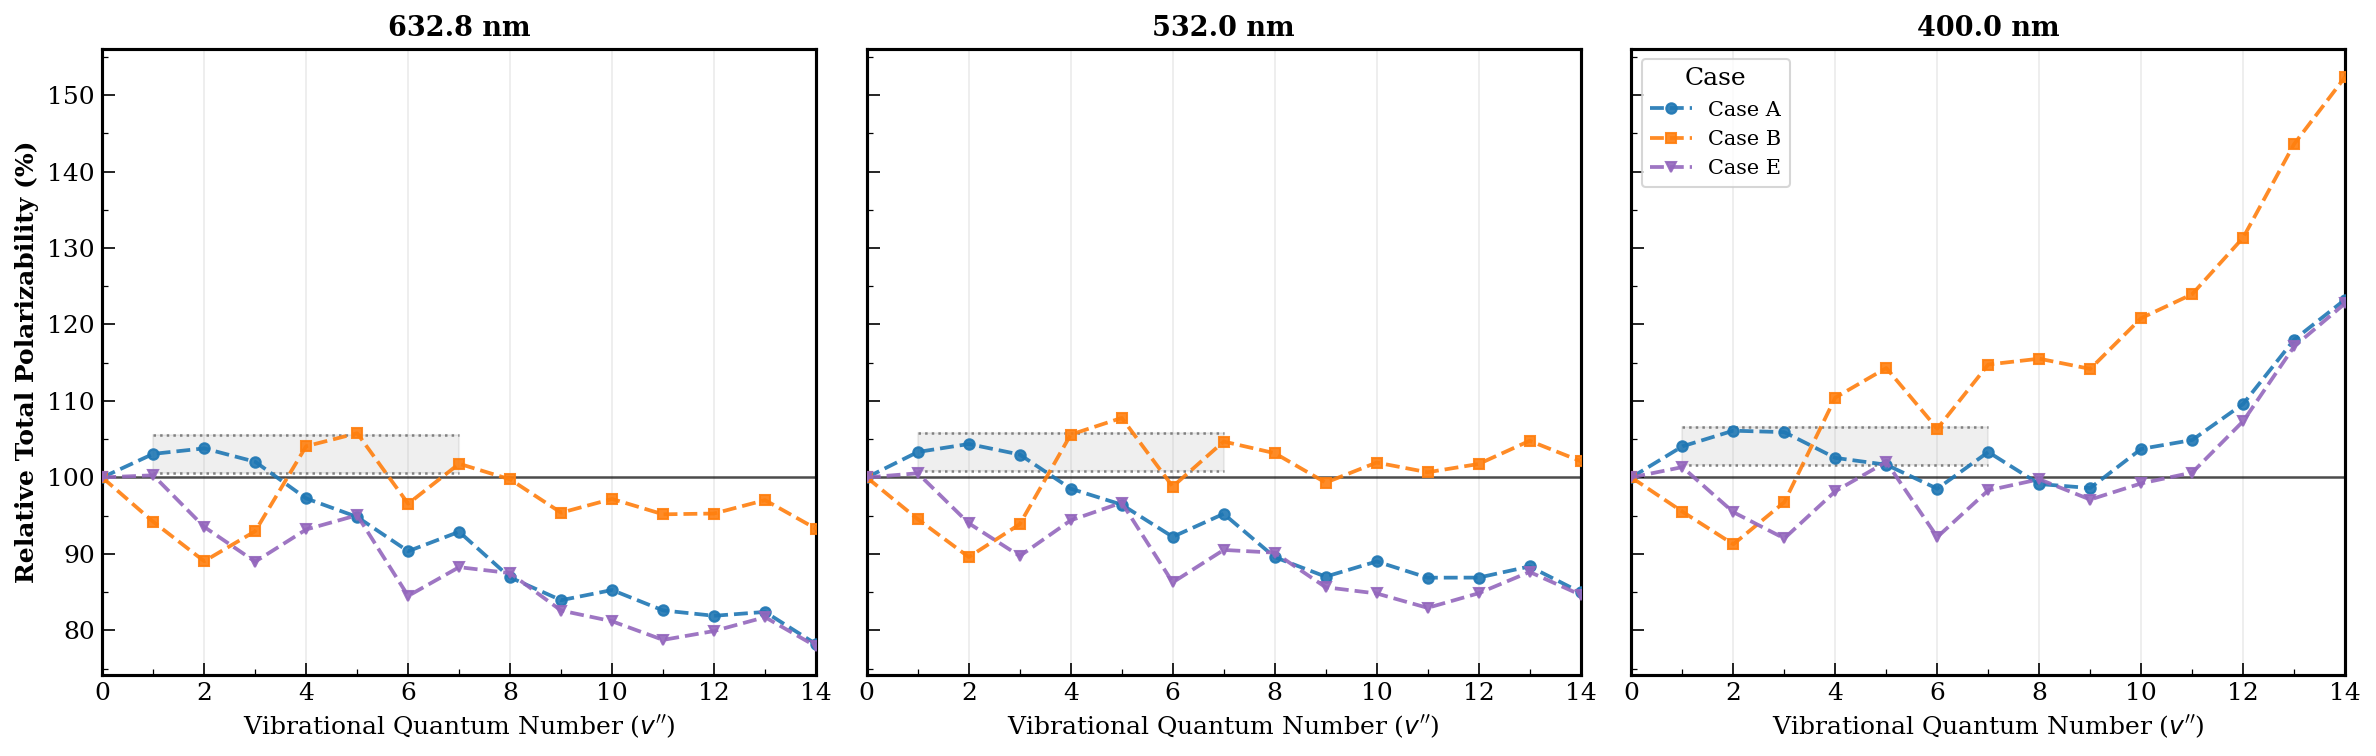

In [30]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator

# Relative total polarizability: same calculation as before, now 1x3 by wavelength
# and with three representative A-E cases overlaid.
try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    case_pol_db_paths = {case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb' for case in active_cases}

MAX_V = 14
FIXED_J = 10
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0
PLOT_CASES = [case for case in ['A', 'B', 'E'] if case in active_cases]

wavelength_config = [
    ('pol_632.8nm', '632.8 nm', '632_8nm'),
    ('pol_532.0nm', '532.0 nm', '532_0nm'),
    ('pol_400.0nm', '400.0 nm', '400_0nm'),
]

case_colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728', 'E': '#9467bd'}
case_markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D', 'E': 'v'}


def _relative_total_for_case(case, wavelength_col):
    wl_sql = f'"{wavelength_col}"'
    query = f"""
    SELECT
        c.down_v,
        c.down_J,
        COALESCE(c.{wl_sql}, 0) AS alpha_cont,
        COALESCE(d.{wl_sql}, 0) AS alpha_disc,
        (COALESCE(c.{wl_sql}, 0) + COALESCE(d.{wl_sql}, 0)) AS alpha_total
    FROM cont_polarizabilities c
    JOIN discrete_polarizabilities d
      ON c.down_v = d.down_v
     AND c.down_J = d.down_J
     AND c.down_omega = d.down_omega
     AND c.down_lambda = d.down_lambda
     AND c.down_sigma = d.down_sigma
    WHERE c.down_v <= {MAX_V}
      AND c.down_J = {FIXED_J}
      AND c.down_omega = {FIXED_OMEGA}
      AND c.down_lambda = {FIXED_LAMBDA}
      AND c.down_sigma = {FIXED_SIGMA}
    ORDER BY c.down_v
    """
    with duckdb.connect(str(case_pol_db_paths[case])) as con:
        df_case = con.execute(query).df()

    if df_case.empty:
        raise ValueError(f'No rows found for case {case}, {wavelength_col}, J={FIXED_J}')

    v0 = df_case.loc[df_case['down_v'] == 0, 'alpha_total']
    if v0.empty:
        raise ValueError(f'No v=0 baseline found for case {case}, {wavelength_col}, J={FIXED_J}')

    df_case['pct_total'] = (df_case['alpha_total'] / v0.iloc[0]) * 100.0
    df_case['case'] = case
    return df_case

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True)
relative_total_data = {}

for ax, (wavelength_col, wavelength_label, safe_name) in zip(axes, wavelength_config):
    relative_total_data[wavelength_col] = {}

    for case in PLOT_CASES:
        df_case = _relative_total_for_case(case, wavelength_col)
        relative_total_data[wavelength_col][case] = df_case
        ax.plot(
            df_case['down_v'],
            df_case['pct_total'],
            label=f'Case {case}',
            color=case_colors.get(case),
            marker=case_markers.get(case, 'o'),
            linestyle='--',
            markersize=5,
            linewidth=1.8,
            alpha=0.9,
            zorder=5,
        )

    ax.axhline(100, color='black', linestyle='-', linewidth=1.2, alpha=0.7, zorder=3)

    # Preserve the tolerance-band idea from the original plot, now panel-wise.
    ref_case = PLOT_CASES[0]
    ref_df = relative_total_data[wavelength_col][ref_case]
    if 1 in set(ref_df['down_v']):
        v1_val = ref_df.loc[ref_df['down_v'] == 1, 'pct_total'].iloc[0]
        tol = 2.5
        lower_bound, upper_bound = v1_val - tol, v1_val + tol
        ax.hlines([lower_bound, upper_bound], xmin=1, xmax=7, colors='gray', linestyles=':', linewidth=1.2, zorder=2)
        ax.fill_betweenx([lower_bound, upper_bound], x1=1, x2=7, color='gray', alpha=0.12, zorder=1)

    ax.set_title(wavelength_label, fontsize=13, fontweight='bold')
    ax.set_xlabel("Vibrational Quantum Number ($v''$)", fontsize=12)
    ax.set_xlim(0, MAX_V)
    ax.set_xticks(range(0, MAX_V + 1, 2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.25, zorder=0)

axes[0].set_ylabel('Relative Total Polarizability (%)', fontsize=12, fontweight='bold')
axes[-1].legend(frameon=True, loc='best', fontsize=10, title='Case')

plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'total_pol_v_dependence_A_B_E_1x3.pdf', dpi=400, bbox_inches='tight')
plt.show()


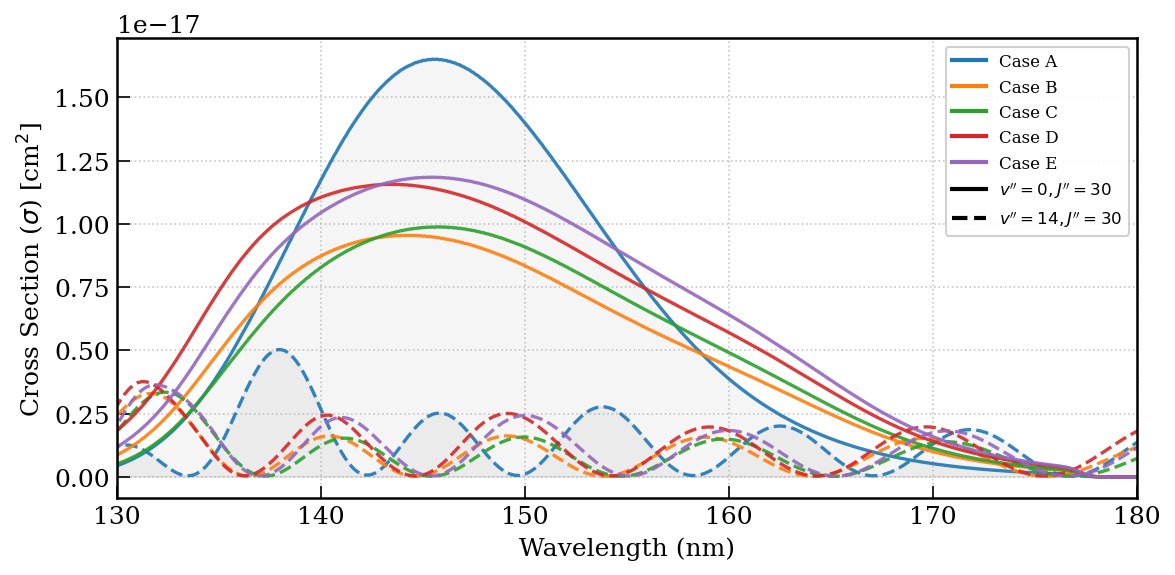

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# Cross-section comparison without case-specific Parquet files.
# Uses in-memory cross_sections_by_case from the A-E computation cell.
try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_FIGURE_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if 'cross_sections_by_case' not in globals():
    print('Skipping cross-section overlay: cross_sections_by_case is not in memory. Run the A-E computation cell first.')
else:
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 12,
        'figure.dpi': 150,
        'grid.alpha': 0.3,
        'legend.frameon': True,
        'legend.fontsize': 9,
        'axes.linewidth': 1.2,
    })

    case_colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728', 'E': '#9467bd'}
    state_defs = [
        {'down_v': 0, 'down_J': 30.0, 'down_lambda': 0.0, 'label': r"$v''=0, J''=30$", 'linestyle': '-'},
        {'down_v': 14, 'down_J': 30.0, 'down_lambda': 0.0, 'label': r"$v''=14, J''=30$", 'linestyle': '--'},
    ]

    def _find_cross_section(case, state_def):
        for entry in cross_sections_by_case.get(case, []):
            if (
                np.isclose(entry.get('down_v'), state_def['down_v'])
                and np.isclose(entry.get('down_J'), state_def['down_J'])
                and np.isclose(entry.get('down_lambda'), state_def['down_lambda'])
            ):
                cs = np.asarray(entry['cross_section'])
                if cs.ndim > 1:
                    cs = cs[0]
                return cs
        return None

    fig, ax = plt.subplots(figsize=(8, 4))
    wavelength_nm = 1e7 / nu_range
    shaded_state_labels = set()

    for case in active_cases:
        for state_idx, state_def in enumerate(state_defs):
            cs = _find_cross_section(case, state_def)
            if cs is None:
                print(f"No cross-section found for case {case}: {state_def['label']}")
                continue

            ax.plot(
                wavelength_nm,
                cs,
                color=case_colors.get(case),
                linestyle=state_def['linestyle'],
                linewidth=1.6,
                alpha=0.9,
                label=f"Case {case}, {state_def['label']}",
            )

            # Preserve the original shaded comparison, but only once per state.
            if state_def['label'] not in shaded_state_labels:
                ax.fill_between(wavelength_nm, cs, color='gray', alpha=0.08)
                shaded_state_labels.add(state_def['label'])

    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel(r'Cross Section ($\sigma$) [cm$^2$]')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_xlim(130, 180)

    case_handles = [Line2D([0], [0], color=case_colors[c], lw=2, label=f'Case {c}') for c in active_cases]
    state_handles = [Line2D([0], [0], color='black', lw=2, linestyle=s['linestyle'], label=s['label']) for s in state_defs]
    ax.legend(handles=case_handles + state_handles, loc='upper right', framealpha=0.9, fontsize=8)

    plt.tight_layout()
    plt.savefig(ABS_FIGURE_DIR / 'cross_section_comparison_AE.pdf', format='pdf', bbox_inches='tight', dpi=400)
    plt.show()



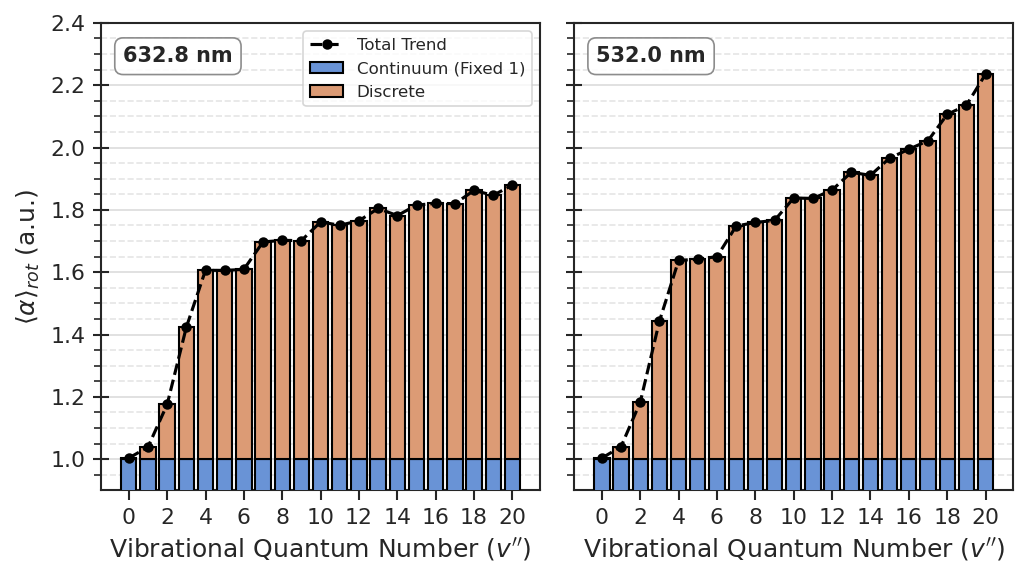

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Constants and Parameters
# ==========================================
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125
T_ROT = 300  # Fixed rotational temperature

# New Theoretical Assumption
CONSTANT_CONT_OFFSET = 1

DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# Fixed quantum numbers
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

# ==========================================
# 2. Database IO (DuckDB)
# ==========================================
# We still pull down_energy from the continuum table to calculate the Boltzmann weights properly,
# but we only need to extract the discrete polarizabilities now.
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.down_energy,
    COALESCE(d."pol_532.0nm", 0) AS disc_532_0nm,
    COALESCE(d."pol_632.8nm", 0) AS disc_632_8nm
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v 
    AND c.down_J = d.down_J
    AND c.down_omega = d.down_omega
    AND c.down_lambda = d.down_lambda
    AND c.down_sigma = d.down_sigma
WHERE 
    c.down_v <= {MAX_V}
    AND c.down_J <= {MAX_J}
    AND c.down_omega = {FIXED_OMEGA}
    AND c.down_lambda = {FIXED_LAMBDA}
    AND c.down_sigma = {FIXED_SIGMA}
ORDER BY 
    c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# Normalize energy
df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY

# ==========================================
# 3. Rotational Boltzmann Averaging per v-level
# ==========================================
exponent = (-h * c * df['delta_E']) / (k_B * T_ROT)
df['weight'] = (2 * df['down_J'] + 1) * np.exp(exponent)

wavelengths = ['532_0nm', '632_8nm']

# Only multiply discrete polarizabilities by weight
for wl in wavelengths:
    df[f'w_disc_{wl}'] = df['weight'] * df[f'disc_{wl}']

agg_dict = {'weight': 'sum'}
for wl in wavelengths:
    agg_dict[f'w_disc_{wl}'] = 'sum'

grouped = df.groupby('down_v').agg(agg_dict).reset_index()

# Calculate final averages and inject the constant continuum offset
for wl in wavelengths:
    grouped[f'avg_disc_{wl}'] = np.where(grouped['weight'] > 0, grouped[f'w_disc_{wl}'] / grouped['weight'], 0.0)
    grouped[f'avg_cont_{wl}'] = CONSTANT_CONT_OFFSET  # <--- Forces the 1.5 base

# ==========================================
# 4. Plotting: Stacked Bar Charts
# ==========================================
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

plot_config = [
    ('532_0nm', '532.0 nm'),
    ('632_8nm', '632.8 nm')
]
plot_config = plot_config[::-1]

cont_color = "#6993D6"  
disc_color = "#DC9B75"  

for i, (col_key, label) in enumerate(plot_config):
    ax = axes[i]
    v_levels = grouped['down_v']
    cont_vals = grouped[f'avg_cont_{col_key}']
    disc_vals = grouped[f'avg_disc_{col_key}']
    
    # Plot Continuum (Flat Base)
    ax.bar(v_levels, cont_vals, label=f'Continuum (Fixed {CONSTANT_CONT_OFFSET})', color=cont_color, edgecolor='black', linewidth=1, zorder=3)
    # Plot Discrete (Stacked)
    ax.bar(v_levels, disc_vals, bottom=cont_vals, label='Discrete', color=disc_color, edgecolor='black', linewidth=1, zorder=3)
     # Plot Trendline (connecting the totals)
    ax.plot(v_levels, (disc_vals + cont_vals), color='black', linestyle='--', marker='o', markersize=4, 
            linewidth=1.5, label='Total Trend', zorder=5)
    # --- Formatting ---
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=10, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9), zorder=4)

    ax.set_xlabel("Vibrational Quantum Number ($v''$)", fontsize=12)
    ax.set_xticks(range(0, MAX_V + 1, 2))
    
    # Bumped y-limit slightly to accommodate the 1.2 offset + discrete values
    ax.set_ylim(1, 2) 
    
    
    # Tick Control
    ax.minorticks_on()
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    # Make major Y ticks cross ('inout')
    ax.tick_params(axis='y', which='major', direction='inout', length=8, width=1)
    ax.set_ylim(0.9,2.4)
    # Grid Control
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.7, zorder=0) 
    ax.grid(True, which='minor', axis='y', linestyle='--', alpha=0.5, zorder=0) 
    ax.grid(False, axis='x') 
    
    if i == 0:
        ax.set_ylabel(r"$\langle\alpha\rangle_{rot}$ (a.u.)", fontsize=12)
        ax.legend(frameon=True, loc='upper right', fontsize=8)
plt.savefig('pol_constantoffset.pdf', dpi=400)
plt.tight_layout()
plt.show()a

Equilibrium polarizability at 632.8 nm


case,A,B,C,D,E
temperature_K,,,,,
300.0,1.622111,1.229879,1.261921,1.601187,1.625834
1200.0,1.632188,1.220965,1.247950,1.610913,1.630822
1700.0,1.631396,1.204243,1.227649,1.605440,1.622784



Full table:
case  temperature_K  continuum_only_A3  total_A3
   A          300.0           1.622111  1.622111
   A         1200.0           1.632188  1.632188
   A         1700.0           1.631396  1.631396
   B          300.0           1.229879  1.229879
   B         1200.0           1.220965  1.220965
   B         1700.0           1.204243  1.204243
   C          300.0           1.261921  1.261921
   C         1200.0           1.247950  1.247950
   C         1700.0           1.227649  1.227649
   D          300.0           1.601187  1.601187
   D         1200.0           1.610913  1.610913
   D         1700.0           1.605440  1.605440
   E          300.0           1.625834  1.625834
   E         1200.0           1.630822  1.630822
   E         1700.0           1.622784  1.622784


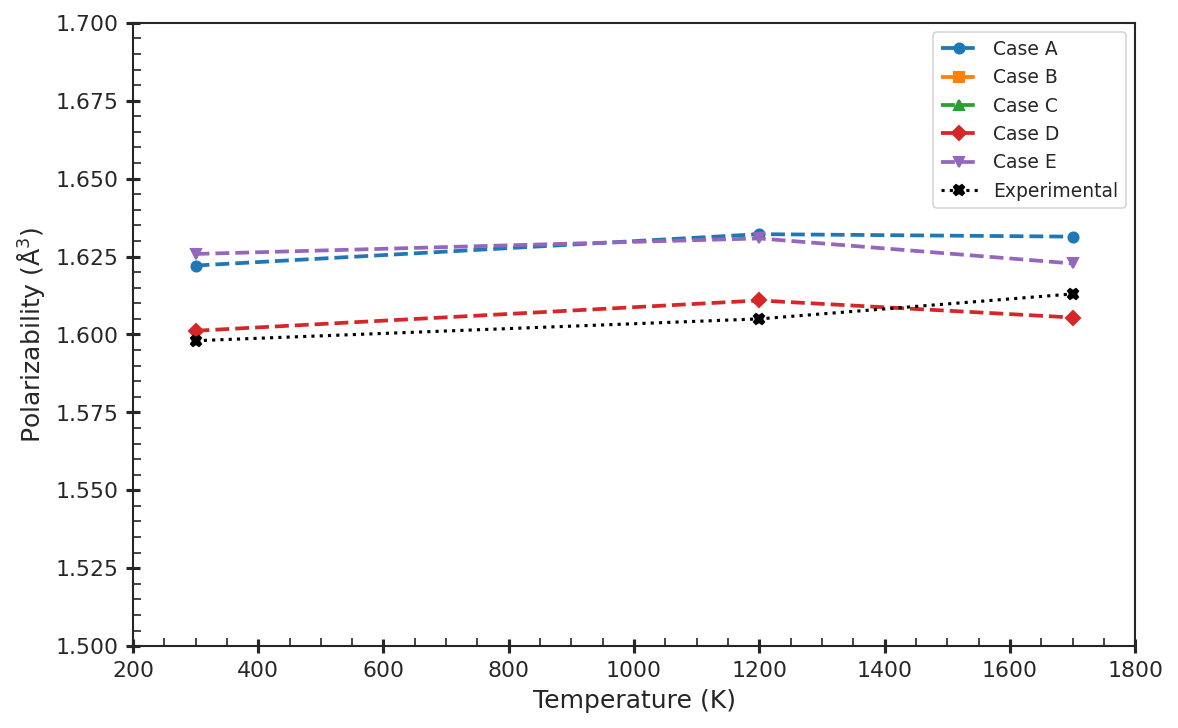

In [37]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter, AutoMinorLocator

# Equilibrium polarizability at 632.8 nm: same figure/table as before,
# now with all five A-E cases overlaid in one plot.
try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    case_pol_db_paths = {case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb' for case in active_cases}

c = 2.99792458e10
h = 6.62607015e-34
k_B = 1.380649e-23

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125
TARGET_WL = 'pol_632.8nm'
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

temps = [300.0, 1200.0, 1700.0]
case_colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728', 'E': '#9467bd'}
case_markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D', 'E': 'v'}


def _load_equilibrium_df(case):
    wl_sql = f'"{TARGET_WL}"'
    query = f"""
    SELECT
        c.down_v,
        c.down_J,
        c.down_energy,
        COALESCE(c.{wl_sql}, 0) AS alpha_cont,
        COALESCE(d.{wl_sql}, 0) AS alpha_disc
    FROM cont_polarizabilities c
    JOIN discrete_polarizabilities d
      ON c.down_v = d.down_v
     AND c.down_J = d.down_J
     AND c.down_omega = d.down_omega
     AND c.down_lambda = d.down_lambda
     AND c.down_sigma = d.down_sigma
    WHERE c.down_v <= {MAX_V}
      AND c.down_J <= {MAX_J}
      AND c.down_omega = {FIXED_OMEGA}
      AND c.down_lambda = {FIXED_LAMBDA}
      AND c.down_sigma = {FIXED_SIGMA}
    ORDER BY c.down_v, c.down_J
    """
    with duckdb.connect(str(case_pol_db_paths[case])) as con:
        df_case = con.execute(query).df()
    df_case['delta_E'] = df_case['down_energy'] - GLOBAL_MIN_ENERGY
    return df_case

equilibrium_records = []
equilibrium_curves = {}

for case in active_cases:
    df_case = _load_equilibrium_df(case)
    computed_total = []
    computed_cont = []

    for T_val in temps:
        exponent = (-h * c * df_case['delta_E']) / (k_B * T_val)
        weight = (2 * df_case['down_J'] + 1) * np.exp(exponent)
        sum_W = weight.sum()

        alpha_cont_macro = (weight * df_case['alpha_cont']).sum() / sum_W
        alpha_total_macro = (weight * (df_case['alpha_cont'] + 0)).sum() / sum_W
    

        computed_cont.append(alpha_cont_macro)
        computed_total.append(alpha_total_macro)
        equilibrium_records.append({
            'case': case,
            'temperature_K': T_val,
            'continuum_only_A3': alpha_cont_macro,
            'total_A3': alpha_total_macro,
        })

    equilibrium_curves[case] = {
        'continuum_only': computed_cont,
        'total': computed_total,
    }

equilibrium_table = pd.DataFrame(equilibrium_records)
print('Equilibrium polarizability at 632.8 nm')
display(equilibrium_table.pivot(index='temperature_K', columns='case', values='total_A3').round(6))
print('\nFull table:')
print(equilibrium_table.round(6).to_string(index=False))

exp_data = [1.598, 1.605, 1.613]
exp_temps = temps[:len(exp_data)]

plt.figure(figsize=(8, 5))
for case in active_cases:
    plt.plot(
        temps,
        equilibrium_curves[case]['total'],
        label=f'Case {case}',
        color=case_colors.get(case),
        linestyle='--',
        marker=case_markers.get(case, 'o'),
        linewidth=1.8,
    )

plt.plot(exp_temps, exp_data, label='Experimental', color='black', linestyle=':', marker='X', linewidth=1.5)
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel(r'$\mathrm{Polarizability}\ (\mathrm{\AA}^3)$', fontsize=12)
plt.ylim(1.500, 1.700)
plt.xlim(200, 1800)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.gca().tick_params(which='major', length=7, width=1.5, direction='inout')
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().tick_params(which='minor', length=4, direction='in')
plt.grid(False)
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'fig_alpha_equilibrium_632nm.jpeg', format='jpeg', dpi=400, bbox_inches='tight')
plt.show()


In [ ]:
import duckdb
from pathlib import Path
import pandas as pd

# Optional combined database: keep the separate A-E DBs, and also collect them
# into one test-case database with case-specific table names.
try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_TEST_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    case_pol_db_paths = {case: ABS_TEST_DIR / f'{case}_polarizabilities.duckdb' for case in active_cases}
    REFERENCE_POL_DB_PATH = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb')

try:
    COMBINED_POL_DB_PATH
except NameError:
    COMBINED_POL_DB_PATH = ABS_TEST_DIR / 'testcase_polarizabilities.duckdb'

COMBINED_POL_DB_PATH.parent.mkdir(parents=True, exist_ok=True)

with duckdb.connect(str(COMBINED_POL_DB_PATH)) as combined:
    combined.execute('CREATE OR REPLACE TABLE case_index (case VARCHAR, source_db VARCHAR, cont_table VARCHAR)')

    for case in active_cases:
        source_path = Path(case_pol_db_paths[case])
        table_name = f'{case}_cont_polarizabilities'

        if source_path.exists():
            source_sql = str(source_path).replace("'", "''")
            combined.execute(f"ATTACH '{source_sql}' AS src_{case}")
            combined.execute(f'CREATE OR REPLACE TABLE "{table_name}" AS SELECT * FROM src_{case}.cont_polarizabilities')
            combined.execute(f'DETACH src_{case}')
            combined.execute('INSERT INTO case_index VALUES (?, ?, ?)', [case, str(source_path), table_name])
        elif 'results_by_case' in globals() and '_prepare_cont_df_for_db' in globals():
            cont_df = _prepare_cont_df_for_db(case, results_by_case[case])
            combined.register('cont_df', cont_df)
            combined.execute(f'CREATE OR REPLACE TABLE "{table_name}" AS SELECT * FROM cont_df')
            combined.unregister('cont_df')
            combined.execute('INSERT INTO case_index VALUES (?, ?, ?)', [case, 'in_memory_results_by_case', table_name])
        else:
            print(f'Skipping case {case}: no source DB and no in-memory results available.')

    # Common discrete table, copied once into the combined DB.
    if Path(REFERENCE_POL_DB_PATH).exists():
        ref_sql = str(REFERENCE_POL_DB_PATH).replace("'", "''")
        combined.execute(f"ATTACH '{ref_sql}' AS ref_pol_db")
        combined.execute('CREATE OR REPLACE TABLE discrete_polarizabilities AS SELECT * FROM ref_pol_db.discrete_polarizabilities')
        combined.execute('DETACH ref_pol_db')
    else:
        print(f'WARNING: reference discrete DB not found: {REFERENCE_POL_DB_PATH}')

print(f'Combined testcase polarizability DB written to: {COMBINED_POL_DB_PATH}')


In [ ]:
import duckdb
from pathlib import Path

try:
    COMBINED_POL_DB_PATH
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    COMBINED_POL_DB_PATH = ABS_TEST_DIR / 'testcase_polarizabilities.duckdb'

with duckdb.connect(str(COMBINED_POL_DB_PATH)) as duckdb_conn:
    print('Combined database case index:')
    display(duckdb_conn.execute('SELECT * FROM case_index ORDER BY case').fetchdf())

    print('Common discrete_polarizabilities preview:')
    display(duckdb_conn.execute('SELECT * FROM discrete_polarizabilities LIMIT 5').fetchdf())


In [ ]:
# import duckdb

# # --- Path to your database ---
# db_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# # --- Connect to the database ---
# duckdb_conn = duckdb.connect(db_path)

# # --- Rename columns to maintain consistency (one decimal place) ---
# # Note: Double quotes are required for column names with dots
# rename_queries = [
#     'ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_400nm TO "pol_400.0nm";',
#     'ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_388nm TO "pol_388.0nm";',
#     'ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_400nm_imag TO "pol_400.0nm_imag";',
#     'ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_388nm_imag TO "pol_388.0nm_imag";'
# ]

# for query in rename_queries:
#     try:
#         duckdb_conn.execute(query)
#         print(f"Executed: {query}")
#     except Exception as e:
#         print(f"Error or column already renamed: {e}")

# # --- Verify the changes ---
# print("\nUpdated Table Schema (First 5 rows):")
# display(duckdb_conn.execute("SELECT * FROM discrete_polarizabilities LIMIT 5").fetchdf())

# duckdb_conn.close()

Executed: ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_400nm TO "pol_400.0nm";
Executed: ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_388nm TO "pol_388.0nm";
Executed: ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_400nm_imag TO "pol_400.0nm_imag";
Executed: ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_388nm_imag TO "pol_388.0nm_imag";

Updated Table Schema (First 5 rows):


,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,pol_632.8nm,pol_532.0nm,pol_400.0nm,pol_388.0nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400.0nm_imag,pol_388.0nm_imag
0,0,0.0,0.0,0.0,0.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
1,0,1.0,0.0,1.0,1.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
2,0,2.0,0.0,0.0,0.0,17.2428,0.003335,0.003459,0.003831,0.003892,0.0,0.0,0.0,0.0
3,0,2.0,0.0,1.0,1.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
4,0,3.0,0.0,1.0,1.0,17.2428,0.003335,0.003459,0.003831,0.003892,0.0,0.0,0.0,0.0


In [ ]:
import duckdb
from pathlib import Path

try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    COMBINED_POL_DB_PATH
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    COMBINED_POL_DB_PATH = ABS_TEST_DIR / 'testcase_polarizabilities.duckdb'

with duckdb.connect(str(COMBINED_POL_DB_PATH)) as duckdb_conn:
    for case in active_cases:
        table_name = f'{case}_cont_polarizabilities'
        print(f'Case {case}: {table_name}')
        display(duckdb_conn.execute(f'SELECT * FROM "{table_name}" LIMIT 5').fetchdf())


In [ ]:
# # Multiplier code, run only once
# import numpy as np

# # Calculate the constant scalar
# # Multiplier = (e^2 * 1e30) / (me * epsilon_0)
# MULTIPLIER_CONT = (1e30 * 3e8) / np.pi

# print(f"Calculated Multiplier: {MULTIPLIER_CONT:.4e}")

# import duckdb

# # Connect to your database
# db_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
# duckdb_conn = duckdb.connect(db_path)

# # Apply the multiplier to the Real and Imaginary components
# # Assuming you have both pol_xxx and pol_xxx_imag columns
# columns_to_update = [
#     "pol_532.0nm", "pol_532.0nm_imag",
#     "pol_388.0nm", "pol_388.0nm_imag",
#     "pol_632.8nm", "pol_632.8nm_imag", 
#     "pol_400.0nm", "pol_400.0nm_imag"
# ]

# # Construct the SET clause: "column" = "column" * MULTIPLIERa
# set_clause = ", ".join([f'"{col}" = "{col}" * {MULTIPLIER_CONT}' for col in columns_to_update])

# try:
#     duckdb_conn.execute(f"UPDATE cont_polarizabilities SET {set_clause}")
#     print("Successfully multiplied columns by physical constants.")
# except Exception as e:
#     print(f"Error: {e}")
#     print("Ensure all column names (including _imag) exist in the table.")

# # Verify a sample
# display(duckdb_conn.execute("SELECT * FROM cont_polarizabilities LIMIT 1").df())

# duckdb_conn.close()

Calculated Multiplier: 9.5493e+37
Successfully multiplied columns by physical constants.


,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,pol_632.8nm,pol_532.0nm,pol_400.0nm,pol_388.0nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400.0nm_imag,pol_388.0nm_imag
0,0,0.0,0.0,0.0,0.0,2.8652,1.583998,1.621004,1.726989,1.743488,0.000022,0.000027,0.000042,0.000044


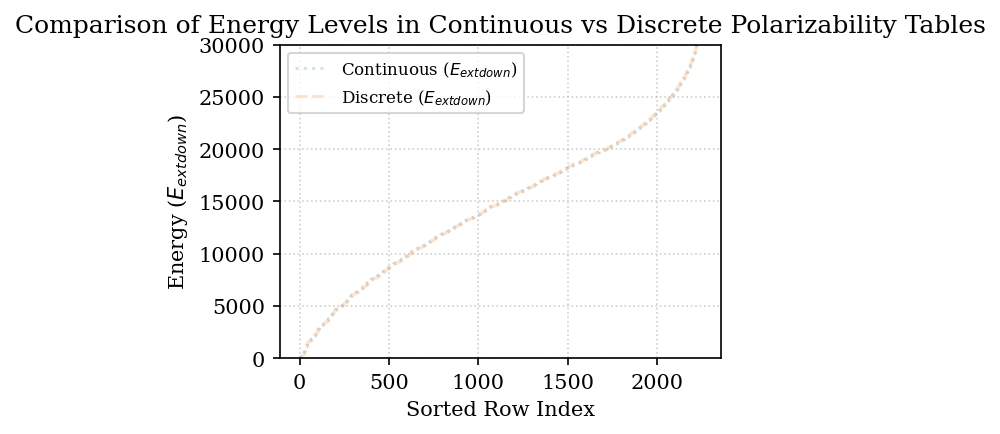

In [40]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to the database
db_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
duckdb_conn = duckdb.connect(db_path)

# 2. Extract down_energy from both tables
# We use .df() to bring them into Pandas for easy sorting and plotting
try:
    df_cont = duckdb_conn.execute("SELECT down_energy FROM cont_polarizabilities where down_v < 15 and down_J<100").df()
    df_disc = duckdb_conn.execute("SELECT down_energy FROM discrete_polarizabilities where down_v < 15 and down_J<100").df()
finally:
    duckdb_conn.close()

# 3. Sort the energies in ascending order
# This allows us to visualize the energy "ladder" or density of states
energies_cont = sorted(df_cont['down_energy'].dropna())
energies_disc = sorted(df_disc['down_energy'].dropna())

# 4. Generate the plot
plt.figure(figsize=(4,3))

# Plotting each as a function of their own index
plt.plot(range(len(energies_cont)), energies_cont, label='Continuous ($E_{\text{down}}$)', 
          linestyle=':', alpha=0.2)
plt.plot(range(len(energies_disc)), energies_disc, label='Discrete ($E_{\text{down}}$)', 
          linestyle='--', alpha=0.2)

# Formatting using LaTeX for scientific notation
plt.xlabel('Sorted Row Index')
plt.ylabel('Energy ($E_{\text{down}}$)')
plt.ylim(0, 30000)  # Adjust as needed to focus on the relevant energy range
plt.title('Comparison of Energy Levels in Continuous vs Discrete Polarizability Tables')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Ensure labels aren't truncated
plt.tight_layout()

# Save the figure to your directory
# plt.savefig('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/energy_plot.png', dpi=300)
# plt.show() # Uncomment if running in an interactive session

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Global thermalized total polarizability for A-E.
# Discrete polarizabilities are common to all cases; continuum varies by case.
try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_FIGURE_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ABS_THESISPLOTS_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots')
DISCRETE_POL_PKL = ABS_THESISPLOTS_DIR / 'full_discrete_pol.pkl'

c = 2.99792458e10
h = 6.62607015e-34
k_B = 1.380649e-23

epsilon_0 = 8.8541878128e-12
me = 9.10938356e-31
e = 1.602176634e-19
MULTIPLIER_CONT = (1e30 * 3e8) / np.pi
MULTIPLIER_DISC = (e**2 * 1e30) / (me * epsilon_0)

wavelength_keys = ['pol_632.8nm', 'pol_532.0nm', 'pol_300.0nm']
target_Temps = np.array([0.10, 500, 1000, 1500, 2000, 2500, 3000])
max_v = 26
case_colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728', 'E': '#9467bd'}
case_markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D', 'E': 'v'}


def _scalar_complex(value):
    if isinstance(value, (np.ndarray, list, tuple)):
        return complex(value[0])
    return complex(value)


def _has_all_keys(record, keys):
    return all(k in record for k in keys)

if 'results_by_case' not in globals():
    raise RuntimeError('results_by_case is not in memory. Run the A-E computation cell first.')
if not DISCRETE_POL_PKL.exists():
    raise FileNotFoundError(f'Discrete polarizability pickle not found: {DISCRETE_POL_PKL}')

df_discrete = pd.read_pickle(DISCRETE_POL_PKL)
discrete_results = df_discrete.to_dict('records')

final_results_by_case = {}

for case in active_cases:
    unified_states = {}

    for r in results_by_case[case]:
        if not _has_all_keys(r, wavelength_keys):
            missing = [k for k in wavelength_keys if k not in r]
            raise KeyError(f'Case {case} is missing continuum keys {missing}. Re-run the computation cell after adding 300 nm to sensing_list.')

        v = r['down_v']
        if v <= max_v:
            J = r['down_J']
            state_key = (v, J)
            unified_states[state_key] = {
                'energy': r['down_energy'],
                'J': J,
                'cont_alphas': {k: (_scalar_complex(r[k]) * MULTIPLIER_CONT).real for k in wavelength_keys},
                'disc_alphas': {k: 0.0 for k in wavelength_keys},
            }

    for r in discrete_results:
        v = r['down_v']
        if v <= max_v:
            J = r['down_J']
            state_key = (v, J)
            if state_key not in unified_states:
                unified_states[state_key] = {
                    'energy': r['down_energy'],
                    'J': J,
                    'cont_alphas': {k: 0.0 for k in wavelength_keys},
                    'disc_alphas': {},
                }

            for k in wavelength_keys:
                if k in r:
                    unified_states[state_key]['disc_alphas'][k] = (_scalar_complex(r[k]) * MULTIPLIER_DISC).real
                else:
                    unified_states[state_key]['disc_alphas'][k] = 0.0

    global_E_min = min(state['energy'] for state in unified_states.values())
    final_results = {k: [] for k in wavelength_keys}

    for T in target_Temps:
        numerators = {k: 0.0 for k in wavelength_keys}
        denominator = 0.0

        for state in unified_states.values():
            J = state['J']
            E_state = state['energy']
            delta_E = E_state - global_E_min
            weight = (2 * J + 1) * np.exp(-h * c * delta_E / (k_B * T))
            denominator += weight

            for k in wavelength_keys:
                total_alpha = state['cont_alphas'].get(k, 0.0) + state['disc_alphas'].get(k, 0.0)
                numerators[k] += total_alpha * weight

        for k in wavelength_keys:
            final_results[k].append(0.0 if denominator == 0 else numerators[k] / denominator)

    final_results_by_case[case] = final_results

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for i, pol_key in enumerate(wavelength_keys):
    ax = axes[i]
    wv_label = pol_key.replace('pol_', '')

    for case in active_cases:
        ax.plot(
            target_Temps,
            final_results_by_case[case][pol_key],
            marker=case_markers.get(case, 'o'),
            linestyle='-',
            color=case_colors.get(case),
            linewidth=1.8,
            markersize=6,
            label=f'Case {case}',
        )

    ax.set_title(f'Thermalized Polarizability at $\lambda = {wv_label}$', fontsize=14)
    ax.set_xlabel('Temperature (K)', fontsize=12)
    if i == 0:
        ax.set_ylabel(r'Global Avg Polarizability ($\langle\alpha\rangle_{T}$)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

plt.suptitle('Global Thermalized Total Polarizability vs Temperature', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'global_thermalized_total_polarizability_AE.pdf', dpi=400, bbox_inches='tight')
plt.show()

print('\n--- Final Fully Thermalized Total Polarizability Values ---')
records = []
for case in active_cases:
    for idx, T in enumerate(target_Temps):
        row = {'case': case, 'Temperature (K)': T}
        for k in wavelength_keys:
            row[k.replace('pol_', '')] = final_results_by_case[case][k][idx]
        records.append(row)

df_final = pd.DataFrame(records)
display(df_final)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D

# Rotational/vibrational thermal averages for A-E.
# Only two rotational temperatures are retained to reduce clutter.
try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

try:
    ABS_FIGURE_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if 'results_by_case' not in globals():
    raise RuntimeError('results_by_case is not in memory. Run the A-E computation cell first.')

c = 2.99792458e10
h = 6.62607015e-34
k_B = 1.380649e-23
MULTIPLIER = (1e30 * 3e8) / np.pi

wavelength_keys = ['pol_632.8nm', 'pol_532.0nm', 'pol_300.0nm']
target_Temps = [1, 2000]
target_T_vib = np.arange(300, 3300, 300)
case_colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728', 'E': '#9467bd'}
temp_linestyles = {1: '-', 2000: '--'}


def _scalar_complex(value):
    if isinstance(value, (np.ndarray, list, tuple)):
        return complex(value[0])
    return complex(value)


def _group_by_v(result_list):
    data_by_v = {}
    for r in result_list:
        v = r['down_v']
        data_by_v.setdefault(v, []).append(r)
    return data_by_v

fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey=False)
thermal_average_results_by_case = {}

for i, pol_key in enumerate(wavelength_keys):
    ax_row1 = axes[0, i]
    ax_row2 = axes[1, i]

    for case in active_cases:
        if any(pol_key not in r for r in results_by_case[case]):
            raise KeyError(f'Case {case} is missing {pol_key}. Re-run the computation cell after adding that sensing wavelength.')

        data_by_v = _group_by_v(results_by_case[case])
        sorted_v_levels = sorted(data_by_v.keys())
        thermal_average_results_by_case.setdefault(case, {}).setdefault(pol_key, {})

        for T_rot in target_Temps:
            v_list = []
            avg_alpha_list = []
            v_energies = []

            for v in sorted_v_levels:
                entries = data_by_v[v]
                E_v_origin = min(r['down_energy'] for r in entries)

                alphas = []
                weights = []
                for r in entries:
                    J = r['down_J']
                    E_rot = r['down_energy']
                    alpha_real = (_scalar_complex(r[pol_key]) * MULTIPLIER).real
                    alphas.append(alpha_real)

                    delta_E = E_rot - E_v_origin
                    factor = (2 * J + 1) * np.exp(-h * c * delta_E / (k_B * T_rot))
                    weights.append(factor)

                weights = np.array(weights)
                weight_sum = np.sum(weights)
                norm_weights = np.zeros_like(weights) if weight_sum == 0 else weights / weight_sum
                weighted_avg_alpha = np.sum(norm_weights * np.array(alphas))

                v_list.append(v)
                avg_alpha_list.append(weighted_avg_alpha)
                v_energies.append(E_v_origin)

            ax_row1.plot(
                v_list,
                avg_alpha_list,
                color=case_colors.get(case),
                linestyle=temp_linestyles[T_rot],
                linewidth=1.6,
                marker='o' if T_rot == 1 else 's',
                markersize=4,
                label=f'Case {case}, $T_{{rot}}$={T_rot} K',
            )

            tot_avg_alphas = []
            E_vib_0 = min(v_energies)
            for T_vib in target_T_vib:
                vib_weights = []
                for E_v in v_energies:
                    delta_E_vib = E_v - E_vib_0
                    vib_weights.append(np.exp(-h * c * delta_E_vib / (k_B * T_vib)))

                vib_weights = np.array(vib_weights)
                Q_vib = np.sum(vib_weights)
                norm_vib_weights = np.zeros_like(vib_weights) if Q_vib == 0 else vib_weights / Q_vib
                tot_avg_alpha = np.sum(norm_vib_weights * np.array(avg_alpha_list))
                tot_avg_alphas.append(tot_avg_alpha)

            thermal_average_results_by_case[case][pol_key][T_rot] = {
                'v_levels': v_list,
                'rot_avg_alpha': avg_alpha_list,
                'T_vib': target_T_vib,
                'vib_total_alpha': tot_avg_alphas,
            }

            ax_row2.plot(
                target_T_vib,
                tot_avg_alphas,
                color=case_colors.get(case),
                linestyle=temp_linestyles[T_rot],
                linewidth=1.6,
                marker='o' if T_rot == 1 else 's',
                markersize=4,
                label=f'Case {case}, $T_{{rot}}$={T_rot} K',
            )

    wv_label = pol_key.replace('pol_', '')
    ax_row1.set_title(f'$\lambda = {wv_label}$', fontsize=14)
    ax_row1.set_xlabel('Vibrational Quantum Number ($v_{down}$)', fontsize=12)
    ax_row1.grid(True, linestyle='--', alpha=0.6)

    ax_row2.set_xlabel('Vibrational Temperature $T_{vib}$ (K)', fontsize=12)
    ax_row2.grid(True, linestyle='--', alpha=0.6)

    if i == 0:
        ax_row1.set_ylabel(r'$\langle\alpha\rangle_{rot}$', fontsize=12)
        ax_row2.set_ylabel(r'Total Avg Polarizability ($\langle\alpha\rangle_{tot}$)', fontsize=12)

case_handles = [Line2D([0], [0], color=case_colors[c], lw=2, label=f'Case {c}') for c in active_cases]
temp_handles = [Line2D([0], [0], color='black', lw=2, linestyle=temp_linestyles[T], label=f'$T_{{rot}}$={T} K') for T in target_Temps]
axes[0, -1].legend(handles=case_handles + temp_handles, fontsize=8, loc='best')
axes[1, -1].legend(handles=case_handles + temp_handles, fontsize=8, loc='best')

plt.suptitle('Polarizability: Rotational and Vibrational Thermal Averages', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'rot_vib_thermal_averages_AE.pdf', dpi=400, bbox_inches='tight')
plt.show()


#### Can now use the above temperature agnostic cross-sections to generate temperature_dependent cross_sections and polarizability. The polarizability however, is raw, meaning it needs to be multipled by several constants.

In [ ]:
import numpy as np
import pandas as pd

c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K

try:
    active_cases
except NameError:
    active_cases = ['A', 'B', 'C', 'D', 'E']

if 'results_by_case' not in globals() or 'cross_sections_by_case' not in globals():
    raise RuntimeError('Run the A-E continuum computation cell first; results_by_case and cross_sections_by_case are required.')

T = [300, 1200, 1700, 3000]
Q_T = [Q(T_i) for T_i in T]
for (T_i, Q_i) in zip(T, Q_T):
    print(f'Partition function at {T_i} K: {Q_i:.6f}')


def _scalar_complex(value):
    if isinstance(value, (np.ndarray, list, tuple)):
        return complex(value[0])
    return complex(value)

master_cross_section_data_by_case = {}
master_polarizability_by_case = {}

for case in active_cases:
    master_cross_section_data_by_case[case] = {}
    master_polarizability_by_case[case] = {}

    result_list = results_by_case[case]
    cross_section_list = cross_sections_by_case[case]
    if len(result_list) != len(cross_section_list):
        raise ValueError(f'Case {case}: results and cross_sections have different lengths.')

    for (T_i, Q_i) in zip(T, Q_T):
        boltz_factors = []
        for r in result_list:
            E = r['down_energy']
            J = r['down_J']
            boltz = (2 * J + 1) * np.exp(-h * c * (E - 2.8652) / (k_B * T_i)) / Q_i
            boltz_factors.append(boltz)

        boltz_factors = np.array(boltz_factors)
        sigma_total = np.zeros_like(nu_range)
        pol_totals = {}

        for r, cs_entry, w in zip(result_list, cross_section_list, boltz_factors):
            cs = np.asarray(cs_entry['cross_section'])
            if cs.ndim > 1:
                cs = cs[0]
            sigma_total += w * cs

            for key, value in r.items():
                if key.startswith('pol_') and key.endswith('nm'):
                    pol_totals.setdefault(key, 0.0 + 0.0j)
                    pol_totals[key] += w * _scalar_complex(value)

        master_cross_section_data_by_case[case][f'CrossSection@{T_i:.1f}K'] = sigma_total
        master_polarizability_by_case[case][f'Polarizability@{T_i:.1f}K'] = pol_totals

# Backward-compatible aliases for single-case cells.
master_cross_section_data = master_cross_section_data_by_case['A']
master_polarizability = master_polarizability_by_case['A']

print('Cases in master_polarizability_by_case:', master_polarizability_by_case.keys())
print('Temperature keys for case A:', master_polarizability_by_case['A'].keys())
master_polarizability_by_case


In [ ]:
import pandas as pd
import numpy as np

scale_factor = 1e30 * 3e8 / np.pi
TARGET_POL_KEY = 'pol_632.8nm'

if 'master_polarizability_by_case' not in globals():
    raise RuntimeError('Run cell 58 first to create master_polarizability_by_case.')

records = []
for case in active_cases:
    for temp_key, pol_dict in master_polarizability_by_case[case].items():
        T_val = float(temp_key.split('@')[1].replace('K', ''))
        if TARGET_POL_KEY not in pol_dict:
            raise KeyError(f'{TARGET_POL_KEY} not found for case {case}, {temp_key}. Available keys: {list(pol_dict.keys())}')
        alpha_A3 = (pol_dict[TARGET_POL_KEY] * scale_factor).real
        records.append({'case': case, 'temperature_K': T_val, TARGET_POL_KEY: alpha_A3})

master_alpha_table = pd.DataFrame(records).sort_values(['temperature_K', 'case'])
print(f'Master continuum polarizability table for {TARGET_POL_KEY}:')
display(master_alpha_table.pivot(index='temperature_K', columns='case', values=TARGET_POL_KEY).round(6))
print('\nLong-form table:')
print(master_alpha_table.round(6).to_string(index=False))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter, AutoMinorLocator

# A-E total-only plot at 300.0 nm. Discrete contribution is common across cases,
# represented by the same temperature-dependent offset used in the original cell.
try:
    ABS_FIGURE_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if 'master_polarizability_by_case' not in globals():
    raise RuntimeError('Run cell 58 first to create master_polarizability_by_case.')

scale_factor = 1e30 * 3e8 / np.pi
temps = [300.0, 1200.0, 1700.0, 3000.0]
offsets = [0.00353, 0.0139, 0.0286, 0.0798]
TARGET_POL_KEY = 'pol_300.0nm'
case_colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728', 'E': '#9467bd'}
case_markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D', 'E': 'v'}

plt.figure(figsize=(8, 5))
total_300_table = []

for case in active_cases:
    total_data = []
    for T_val, offset in zip(temps, offsets):
        pol_dict = master_polarizability_by_case[case][f'Polarizability@{T_val}K']
        if TARGET_POL_KEY not in pol_dict:
            raise KeyError(f'{TARGET_POL_KEY} not found for case {case}. Re-run the computation cell after adding 300 nm to sensing_list.')
        alpha = pol_dict[TARGET_POL_KEY]
        scaled_total = (alpha * scale_factor).real + offset
        total_data.append(scaled_total)
        total_300_table.append({'case': case, 'temperature_K': T_val, 'total_A3': scaled_total})

    plt.plot(
        temps,
        total_data,
        label=f'Case {case}',
        color=case_colors.get(case),
        linestyle='-',
        marker=case_markers.get(case, 'o'),
        linewidth=1.8,
    )

plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel(r'$\mathrm{Polarizability}\ (\mathrm{\AA}^3)$', fontsize=12)
plt.title('Total Polarizability at 300.0 nm vs Temperature', fontsize=14)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.gca().tick_params(which='major', length=7, width=1.5, direction='inout')
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().tick_params(which='minor', length=4, direction='in')
plt.grid(False)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'total_polarizability_300nm_AE.pdf', dpi=400, bbox_inches='tight')
plt.show()

total_300_table = pd.DataFrame(total_300_table)
display(total_300_table.pivot(index='temperature_K', columns='case', values='total_A3').round(6))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter, AutoMinorLocator

# A-E total-only plot at 632.8 nm. Discrete contribution is common across cases,
# represented by the same temperature-dependent offset used in the original cell.
try:
    ABS_FIGURE_DIR
except NameError:
    ABS_TEST_DIR = Path('/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/tests')
    ABS_FIGURE_DIR = ABS_TEST_DIR / 'figures'
    ABS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if 'master_polarizability_by_case' not in globals():
    raise RuntimeError('Run cell 58 first to create master_polarizability_by_case.')

scale_factor = 1e30 * 3e8 / np.pi
temps = [300.0, 1200.0, 1700.0, 3000.0]
offsets = [0.00353, 0.0139, 0.0286, 0.0798]
TARGET_POL_KEY = 'pol_632.8nm'
case_colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728', 'E': '#9467bd'}
case_markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D', 'E': 'v'}

exp_data = [1.598, 1.605, 1.613]
exp_temps = temps[:len(exp_data)]

plt.figure(figsize=(8, 5))
total_632_table = []

for case in active_cases:
    total_data = []
    for T_val, offset in zip(temps, offsets):
        pol_dict = master_polarizability_by_case[case][f'Polarizability@{T_val}K']
        if TARGET_POL_KEY not in pol_dict:
            raise KeyError(f'{TARGET_POL_KEY} not found for case {case}.')
        alpha = pol_dict[TARGET_POL_KEY]
        scaled_total = (alpha * scale_factor).real + offset
        total_data.append(scaled_total)
        total_632_table.append({'case': case, 'temperature_K': T_val, 'total_A3': scaled_total})

    plt.plot(
        temps,
        total_data,
        label=f'Case {case}',
        color=case_colors.get(case),
        linestyle='-',
        marker=case_markers.get(case, 'o'),
        linewidth=1.8,
    )

plt.scatter(exp_temps, exp_data, label='Experimental', color='black', marker='X', s=90, edgecolors='black', zorder=10)
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel(r'$\mathrm{Polarizability}\ (\mathrm{\AA}^3)$', fontsize=12)
plt.ylim(1.400, 1.900)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.gca().tick_params(which='major', length=7, width=1.5, direction='inout')
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().tick_params(which='minor', length=4, direction='in')
plt.grid(False)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ABS_FIGURE_DIR / 'total_polarizability_632nm_AE.pdf', dpi=400, bbox_inches='tight')
plt.show()

total_632_table = pd.DataFrame(total_632_table)
display(total_632_table.pivot(index='temperature_K', columns='case', values='total_A3').round(6))
